# 서울시 부동산 투자유형별 분석 (2018~2024)
## 분석 목적
투자자 성향(안전형 / 중립형 / 공격형)에 따라 서울 25개 자치구 + 4개 건물유형의
최적 투자 지역 및 건물유형을 데이터 기반으로 추천합니다.

## 분석 프레임워크
| 지표 | 의미 | 방향 |
|------|------|------|
| 성장성 | 평균 연간 평당가격 상승률 | 높을수록 좋음 ↑ |
| 가격 | 서울 평균 대비 현재 평당가격 | 낮을수록 저평가 ↓ |
| 변동성 | 상승률의 표준편차 | 낮을수록 안정적 ↓ |

→ 3개 지표를 **Z-score 표준화** 후 투자 성향별 가중치 합산

## 전처리 방침 — 이원화 근거
이 노트북은 **IQR 기반 가격 이상치를 제거**합니다.
> Z-score를 이용한 자치구 간 공정 비교를 위해서는 정제된 데이터가 필요합니다.
> ※ 시장 전체 흐름 분석은 별도 노트북(서울시_부동산_시장조사.ipynb)에서 원본 데이터를 사용합니다.

## 가중치 설계
| 투자 성향 | 성장성 | 가격 | 변동성 | 합계 |
|----------|--------|------|--------|------|
| 안전형 | 0.5 | 1.0 | **1.5** | 3.0 |
| 중립형 | 1.0 | 1.0 | 1.0 | 3.0 |
| 공격형 | **1.5** | 1.0 | 0.5 | 3.0 |

※ 모든 유형 가중치 합 = 3.0 → 성향 간 점수 스케일 동일 (공정 비교 가능)


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 한글 폰트 설정 (Mac: AppleGothic / Windows: Malgun Gothic / Linux: NanumGothic)
import platform
if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

In [2]:
# 데이터 로딩 (상대 경로 사용 → data/ 폴더에 CSV 저장 필요)
data_2018 = pd.read_csv('/Users/joshuakim/Desktop/스파르타 포트폴리오/서울 부동산 project 1/seoul_real_estate_dataset/2018.csv', encoding="euc-kr",low_memory = False)
data_2019 = pd.read_csv('/Users/joshuakim/Desktop/스파르타 포트폴리오/서울 부동산 project 1/seoul_real_estate_dataset/2019.csv', encoding="euc-kr",low_memory = False)
data_2020 = pd.read_csv('/Users/joshuakim/Desktop/스파르타 포트폴리오/서울 부동산 project 1/seoul_real_estate_dataset/2020.csv', encoding="euc-kr",low_memory = False)
data_2021 = pd.read_csv('/Users/joshuakim/Desktop/스파르타 포트폴리오/서울 부동산 project 1/seoul_real_estate_dataset/2021.csv', encoding="euc-kr",low_memory = False)
data_2022 = pd.read_csv('/Users/joshuakim/Desktop/스파르타 포트폴리오/서울 부동산 project 1/seoul_real_estate_dataset/2022.csv', encoding="euc-kr",low_memory = False) 
data_2023 = pd.read_csv('/Users/joshuakim/Desktop/스파르타 포트폴리오/서울 부동산 project 1/seoul_real_estate_dataset/2023.csv', encoding="euc-kr",low_memory = False)
data_2024 = pd.read_csv('/Users/joshuakim/Desktop/스파르타 포트폴리오/서울 부동산 project 1/seoul_real_estate_dataset/2024.csv', encoding="euc-kr",low_memory = False)

In [3]:
# 모든 데이터를 하나의 리스트로 만든 후 통합
# join="inner": 연도별 CSV의 컬럼이 다를 수 있으므로 공통 컬럼만 사용
dfs = [data_2018, data_2019, data_2020, data_2021, data_2022, data_2023, data_2024]
df_all = pd.concat(dfs, axis=0, ignore_index=True, join="inner")
print("통합 데이터 크기:", df_all.shape)

통합 데이터 크기: (833614, 21)


In [4]:
# 거래 취소건 데이터에서 제거 → 실제 완료된 거래만 분석 대상
df_all = df_all[df_all["취소일"].isna()]
print("거래 취소 건 제거 후:", df_all.shape)

거래 취소 건 제거 후: (808073, 21)


## EDA — IQR 이상치 제거 전 데이터 탐색

In [ ]:
# ── EDA: IQR 이상치 제거 전 분포 확인 ──────────────────────────────
# 제거 전 기초 통계
before_count = len(df_all)
before_mean = df_all["물건금액(만원)"].mean()
before_std = df_all["물건금액(만원)"].std()

print(f"[제거 전] 행 수: {before_count:,} / 평균: {before_mean:,.0f}만원 / 표준편차: {before_std:,.0f}만원")
print()

# 결측값 비율
null_rate = (df_all.isnull().sum() / len(df_all) * 100).round(2)
null_df = null_rate[null_rate > 0].sort_values(ascending=False)
print("결측값 비율 (있는 컬럼만):")
print(null_df.to_string())

[제거 전] 행 수: 808,073 / 평균: 63,835만원 / 표준편차: 71,754만원

결측값 비율 (있는 컬럼만):
취소일                 100.00
권리구분                 99.09
신고한 개업공인중개사 시군구명     78.43
신고구분                 73.55
토지면적(㎡)              20.00
지번구분                  6.73
지번구분명                 6.73
본번                    6.73
부번                    6.73
건물명                   6.72
층                     6.72
건축년도                  0.41


## 전처리

In [6]:
# 가격 이상치 제거 (IQR 기반)
# [이원화 근거] Z-score 공정 비교를 위해 극단값 제거가 필요합니다.
# IQR(사분위 범위)의 1.5배를 벗어나는 거래금액을 이상치로 정의합니다.
# → 이상치가 포함되면 특정 자치구의 Z-score가 왜곡되어 순위 결과가 신뢰 불가능해집니다.
# ※ 시장조사 노트북은 원본 유지 / 이 노트북만 IQR 정제 적용 (이원화)

Q1 = df_all["물건금액(만원)"].quantile(0.25)
Q3 = df_all["물건금액(만원)"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_before = df_all.copy()  # 비교를 위해 제거 전 데이터 보관
df_all = df_all[(df_all["물건금액(만원)"] >= lower) & (df_all["물건금액(만원)"] <= upper)]
print("거래금액 이상치 제거 후:", df_all.shape)
print(f"  → 하한: {lower:,.0f}만원 / 상한: {upper:,.0f}만원")
print(f"  → 제거된 행 수: {len(df_before) - len(df_all):,}건 ({(len(df_before)-len(df_all))/len(df_before)*100:.1f}%)")

거래금액 이상치 제거 후: (757070, 21)
  → 하한: -58,600만원 / 상한: 163,000만원
  → 제거된 행 수: 51,003건 (6.3%)


## EDA — IQR 이상치 제거 전후 비교

제거 전: 808,073건
제거 후: 757,070건
제거된 건수: 51,003건 (6.3%)
평균 변화: 63,835 → 50,868만원


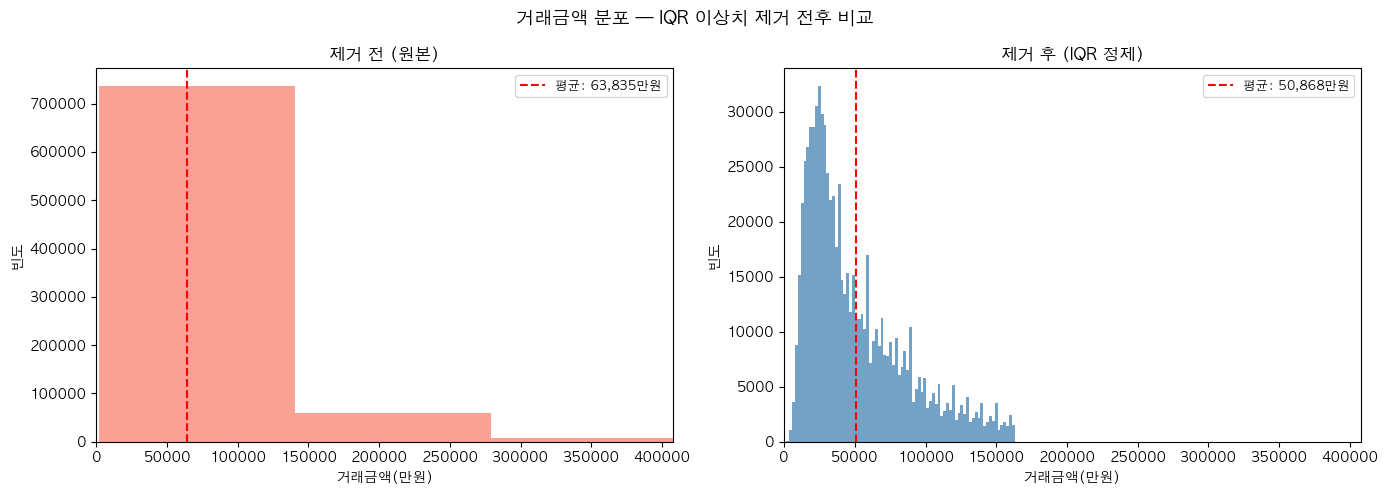

In [ ]:
# EDA: IQR 이상치 제거 전후 분포 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("거래금액 분포 — IQR 이상치 제거 전후 비교", fontsize=13, fontweight="bold")

for ax, df_plot, title, color in [
    (axes[0], df_before, "제거 전 (원본)", "salmon"),
    (axes[1], df_all,   "제거 후 (IQR 정제)", "steelblue"),
]:
    ax.hist(df_plot["물건금액(만원)"].dropna(), bins=80,
            color=color, alpha=0.75, edgecolor="none")
    ax.set_title(title)
    ax.set_xlabel("거래금액(만원)")
    ax.set_ylabel("빈도")
    mean_val = df_plot["물건금액(만원)"].mean()
    ax.axvline(mean_val, color="red", linestyle="--", linewidth=1.5,
               label=f"평균: {mean_val:,.0f}만원")
    ax.legend(fontsize=9)
    ax.set_xlim(0, df_before["물건금액(만원)"].quantile(0.995))

# 제거 전후 수치 요약
before_n = len(df_before)
after_n  = len(df_all)
removed  = before_n - after_n
print(f"제거 전: {before_n:,}건")
print(f"제거 후: {after_n:,}건")
print(f"제거된 건수: {removed:,}건 ({removed/before_n*100:.1f}%)")
print(f"평균 변화: {df_before['물건금액(만원)'].mean():,.0f} → {df_all['물건금액(만원)'].mean():,.0f}만원")

plt.tight_layout()
plt.show()

In [8]:
# 건축연도 정제
df_all = df_all.copy()
df_all["건축년도"] = pd.to_numeric(df_all["건축년도"], errors="coerce")
current_year = pd.Timestamp.today().year
df_all = df_all[(df_all["건축년도"] >= 1900) & (df_all["건축년도"] <= current_year)]
print("건축연도 정제 후:", df_all.shape)

건축연도 정제 후: (747374, 21)


In [9]:
# 건물면적 → 평수 및 평당가격 계산
df_all["건물면적(㎡)"] = pd.to_numeric(df_all["건물면적(㎡)"], errors="coerce")

# 평수 및 평당가격 구하기
df_all["평수"] = df_all["건물면적(㎡)"] / 3.3
df_all["평당가격"] = df_all["물건금액(만원)"] / df_all["평수"]

# 연도별 평균 평당 가격
avg_py_year = (df_all.groupby("접수연도")["평당가격"].mean().reset_index())
avg_py_year["평당가격"] = avg_py_year["평당가격"].round(1)
print(avg_py_year)

# 실제 건물용도 카테고리 확인 → PPT의 4개 유형과 매칭 확인
print("\n건물용도 카테고리:")
print(df_all["건물용도"].value_counts())

   접수연도    평당가격
0  2018  2271.4
1  2019  2587.3
2  2020  2742.6
3  2021  2936.6
4  2022  2891.1
5  2023  3317.8
6  2024  3552.5

건물용도 카테고리:
건물용도
아파트      340152
연립다세대    281033
오피스텔      83000
단독다가구     43189
Name: count, dtype: int64


In [44]:
# 계약일 파싱 → 계약연도/월 분리
# 향후 월별 계절성 분석, 분기별 트렌드 분석 등에 활용 가능하도록 분리합니다.
df_all = df_all.copy()
df_all["계약일"] = pd.to_datetime(df_all["계약일"], errors="coerce", format="%Y%m%d")
df_all["계약연도"] = df_all["계약일"].dt.year
df_all["계약월"]  = df_all["계약일"].dt.month

print("계약일 처리 후:", df_all[["계약일", "계약연도", "계약월"]].head())
print(df_all.shape)

계약일 처리 후:          계약일  계약연도  계약월
0 2019-04-25  2019    4
1 2019-03-16  2019    3
2 2019-02-21  2019    2
3 2019-01-21  2019    1
4 2019-01-03  2019    1
(747374, 25)


## 자치구별 기초 분석

In [11]:
# 자치구별 평균 집값 비교
avg_price_gu = df_all.groupby("자치구명")["물건금액(만원)"].mean().reset_index()
avg_price_gu["물건금액(만원)"] = avg_price_gu["물건금액(만원)"].round(2)
avg_price_gu = avg_price_gu.sort_values("물건금액(만원)", ascending=False).reset_index(drop=True)
print(avg_price_gu)

    자치구명  물건금액(만원)
0    성동구  82094.57
1    용산구  67570.54
2    서초구  66012.56
3    동작구  65041.10
4    강남구  65031.02
5    송파구  62824.51
6     중구  60605.07
7    마포구  59248.01
8    강동구  58900.20
9   영등포구  57168.08
10   광진구  55054.87
11  서대문구  54410.30
12  동대문구  51878.50
13   성북구  51810.46
14   양천구  50622.27
15   종로구  49838.52
16   노원구  46233.00
17   관악구  43161.51
18   중랑구  42120.80
19   구로구  40500.76
20   강서구  40094.48
21   은평구  38113.55
22   금천구  35549.38
23   도봉구  34773.83
24   강북구  33973.28


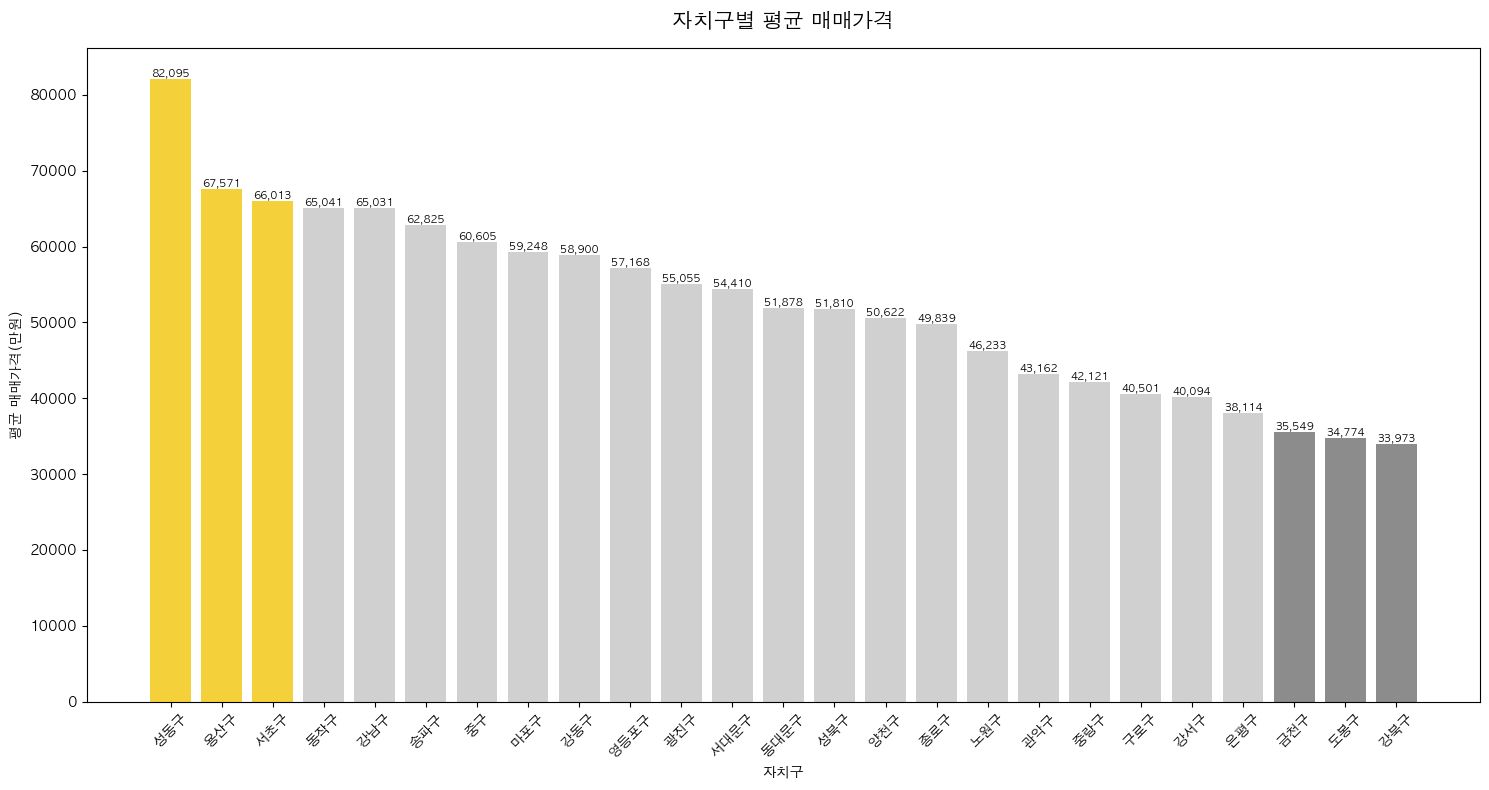

In [12]:
# 자치구별 평균 매매가격 시각화
avg_price_gu_sorted = avg_price_gu.sort_values("물건금액(만원)", ascending=False).reset_index(drop=True)

colors = []
for i in range(len(avg_price_gu_sorted)):
    if i < 3:
        colors.append("#F4D13B")
    elif i >= len(avg_price_gu_sorted) - 3:
        colors.append("#8C8C8C")
    else:
        colors.append("#D0D0D0")

plt.figure(figsize=(15, 8))
plt.bar(avg_price_gu_sorted["자치구명"], avg_price_gu_sorted["물건금액(만원)"], color=colors)
plt.title("자치구별 평균 매매가격", fontsize=15, fontweight="bold", pad=15)
plt.xlabel("자치구")
plt.ylabel("평균 매매가격(만원)")
plt.xticks(rotation=45)
for i, v in enumerate(avg_price_gu_sorted["물건금액(만원)"]):
    plt.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=7.5)
plt.tight_layout()
plt.show()

In [13]:
# 자치구별 평균 평당 가격 계산
gu_avg_py = df_all.groupby("자치구명")["평당가격"].mean().reset_index()
gu_avg_py["평당가격"] = gu_avg_py["평당가격"].round(2)
gu_avg_py = gu_avg_py.sort_values("평당가격", ascending=False).reset_index(drop=True)
print(gu_avg_py)

    자치구명     평당가격
0    강남구  4361.82
1    용산구  4089.75
2    성동구  4017.59
3    서초구  3858.76
4    송파구  3517.79
5    마포구  3415.35
6     중구  3312.33
7    동작구  3228.46
8   영등포구  3182.59
9    강동구  3132.77
10   광진구  2955.85
11  동대문구  2807.20
12  서대문구  2749.10
13   종로구  2739.47
14   양천구  2601.35
15   성북구  2502.73
16   노원구  2484.62
17   강서구  2424.37
18   관악구  2306.98
19   금천구  2205.51
20   중랑구  2197.89
21   은평구  2177.04
22   구로구  2173.11
23   도봉구  1832.33
24   강북구  1818.83


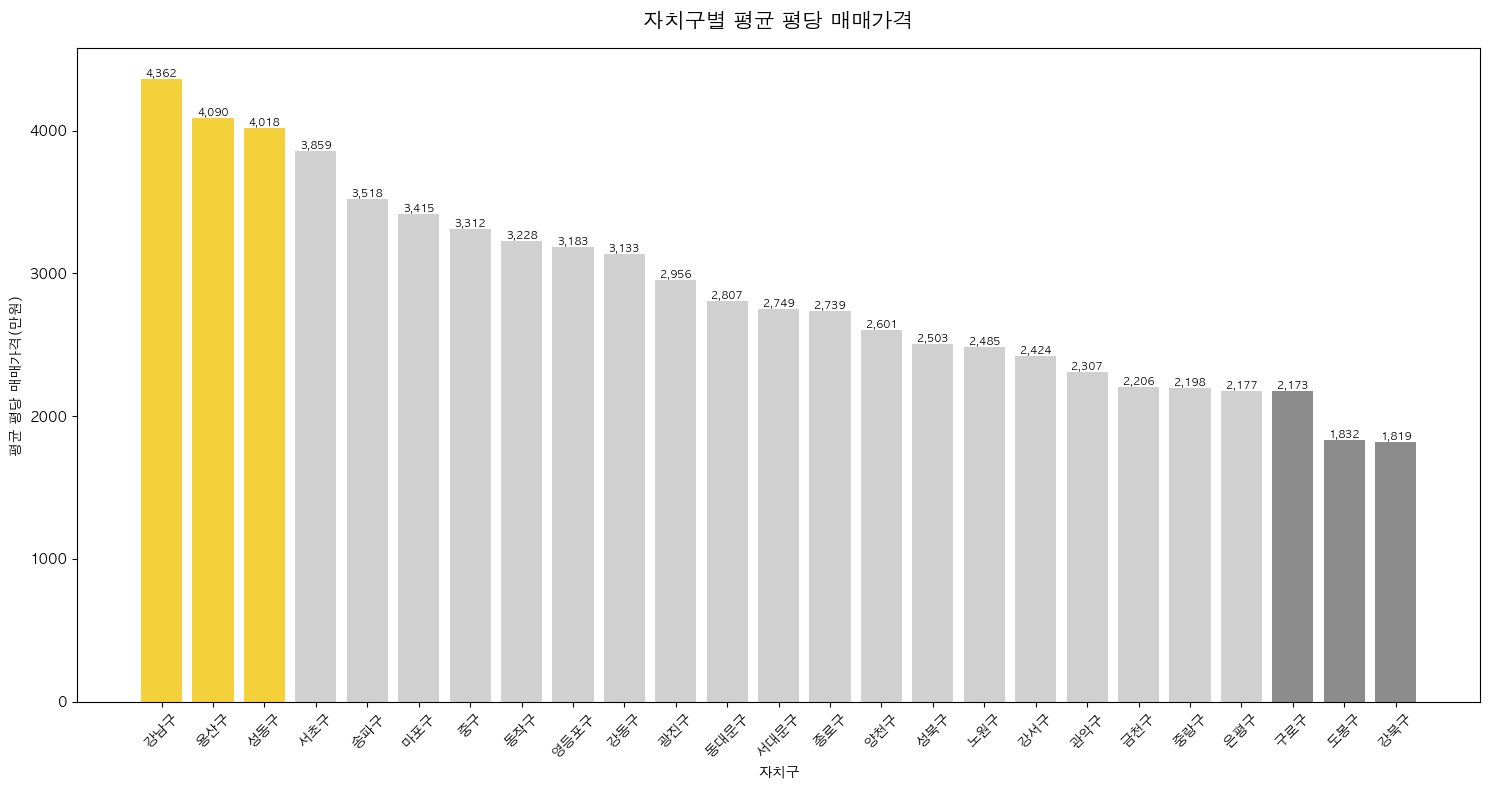

In [14]:
# 자치구별 평균 평당 매매가격 시각화
gu_avg_py_g = gu_avg_py.sort_values("평당가격", ascending=False).reset_index(drop=True)

colors = []
for i in range(len(gu_avg_py_g)):
    if i < 3:
        colors.append("#F4D13B")
    elif i >= len(gu_avg_py_g) - 3:
        colors.append("#8C8C8C")
    else:
        colors.append("#D0D0D0")

plt.figure(figsize=(15, 8))
plt.bar(gu_avg_py_g["자치구명"], gu_avg_py_g["평당가격"], color=colors)
plt.title("자치구별 평균 평당 매매가격", fontsize=15, fontweight="bold", pad=15)
plt.xlabel("자치구")
plt.ylabel("평균 평당 매매가격(만원)")
plt.xticks(rotation=45)
for i, v in enumerate(gu_avg_py_g["평당가격"]):
    plt.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=7.5)
plt.tight_layout()
plt.show()

## 핵심 지표 계산 (성장성 / 가격 / 변동성)

In [15]:
# 연도별·자치구별 평당가격 피벗 테이블 생성
price_diff_gu_year = df_all.pivot_table(
    index="자치구명", columns="접수연도", values="평당가격", aggfunc="mean"
)
price_diff_gu_year = price_diff_gu_year.reset_index()
years = sorted(df_all["접수연도"].unique())
print(price_diff_gu_year)

접수연도  자치구명         2018         2019         2020         2021         2022  \
0      강남구  4021.585014  4474.598202  4350.148373  4225.057126  4161.327118   
1      강동구  2502.806166  2828.401078  3107.395214  3260.913263  3053.671938   
2      강북구  1532.614897  1657.821076  1823.582361  1913.211937  1865.668775   
3      강서구  1973.061418  2108.113670  2461.299682  2637.853403  2538.233395   
4      관악구  1878.948860  2097.073969  2333.947515  2517.427814  2594.906972   
5      광진구  2390.683009  2710.791516  2915.592896  3025.465492  3093.883329   
6      구로구  1780.671562  1992.961657  2151.474489  2402.537392  2290.078533   
7      금천구  1589.115402  1876.083840  2138.233480  2352.023216  2600.135493   
8      노원구  1896.717994  2177.111407  2549.136805  3147.842891  2876.640843   
9      도봉구  1500.855953  1667.756784  1873.964083  1989.940085  1942.023246   
10    동대문구  2145.294090  2573.876114  2917.152870  3223.304029  2885.523609   
11     동작구  2491.370732  2958.409826  3232.565534  3

In [16]:
# 각 연도별 평당 가격 상승률 계산
gu_growth_yearly_diff = price_diff_gu_year.copy()

for i in range(1, len(years)):
    pre_y = years[i-1]
    cur_y = years[i]
    col_name = f"{pre_y}->{cur_y} 상승률(%)"
    gu_growth_yearly_diff[col_name] = (
        (gu_growth_yearly_diff[cur_y] - gu_growth_yearly_diff[pre_y])
        / gu_growth_yearly_diff[pre_y] * 100
    )

In [17]:
# 자치구별 평균 상승률 및 변동성 계산
growth_cols = [c for c in gu_growth_yearly_diff.columns if "상승률(%)" in str(c)]

# 성장성: 자치구별 평균 상승률
gu_growth_yearly_diff["평균상승률(%)"] = gu_growth_yearly_diff[growth_cols].mean(axis=1).round(4)

# 변동성: 상승률의 표준편차 → 값이 클수록 가격 불안정 (안전형 투자자에게 불리)
gu_growth_yearly_diff["상승률변동성"] = gu_growth_yearly_diff[growth_cols].std(axis=1).round(4)

print(gu_growth_yearly_diff[["자치구명", "평균상승률(%)", "상승률변동성"]])

접수연도  자치구명  평균상승률(%)   상승률변동성
0      강남구    4.3690   9.0951
1      강동구    9.1728   9.9606
2      강북구    6.5096   5.4154
3      강서구    6.9224   6.5783
4      관악구    6.6624   4.4576
5      광진구    8.6610   4.9385
6      구로구    7.3254   6.1811
7      금천구    9.9337   6.2191
8      노원구    8.6644  11.8385
9      도봉구    6.2352   5.3723
10    동대문구    9.2666  10.3244
11     동작구    9.2678   9.0893
12     마포구    7.9763   7.1122
13    서대문구    9.5813   6.5230
14     서초구    4.8968   6.4986
15     성동구    9.0895  10.2015
16     성북구    9.8021   9.9615
17     송파구    6.3684   9.9031
18     양천구    9.4703  15.7081
19    영등포구    8.7289   6.5157
20     용산구    8.7127   8.5657
21     은평구    8.2613   5.8234
22     종로구    5.9749   6.3784
23      중구    7.5008   8.5769
24     중랑구    9.6135   4.9875


In [18]:
# 상대적 평가 → 자치구 평균 평당 가격 vs 서울 전체 평균 평당 가격
# 가격·상승률과 같이 보았을 때 어느 정도의 투자 가치를 판별 가능하다

latest_year = years[-1]

# 자치구별 현재 평균 가격 (2024년 기준)
gu_growth_yearly_diff["현재평당가격"] = gu_growth_yearly_diff[latest_year]

# 서울 전체 평균 가격
seoul_total_avg_price = gu_growth_yearly_diff["현재평당가격"].mean()
print(f"서울 평균 평당가격: {seoul_total_avg_price:,.0f}만원")

# 상대가격비율 해석: 1.0 = 서울 평균 / 1.39 = 서울 평균보다 39% 비쌈 / 0.8 = 20% 저렴
gu_growth_yearly_diff["상대적가격비율"] = (
    gu_growth_yearly_diff["현재평당가격"] / seoul_total_avg_price
)
print(gu_growth_yearly_diff[["자치구명", "현재평당가격", "상대적가격비율"]])

서울 평균 평당가격: 3,632만원
접수연도  자치구명       현재평당가격   상대적가격비율
0      강남구  5103.671921  1.405284
1      강동구  4148.979724  1.142411
2      강북구  2222.827718  0.612050
3      강서구  2920.065049  0.804033
4      관악구  2754.713287  0.758504
5      광진구  3914.766846  1.077922
6      구로구  2697.727478  0.742813
7      금천구  2782.298210  0.766099
8      노원구  3029.327400  0.834118
9      도봉구  2143.524745  0.590214
10    동대문구  3563.418788  0.981179
11     동작구  4162.095024  1.146023
12     마포구  4342.366050  1.195660
13    서대문구  3636.241147  1.001230
14     서초구  4526.005677  1.246225
15     성동구  5218.611308  1.436932
16     성북구  3263.859936  0.898696
17     송파구  4334.435610  1.193476
18     양천구  3526.301772  0.970959
19    영등포구  4047.515231  1.114473
20     용산구  5499.580157  1.514296
21     은평구  2802.291726  0.771604
22     종로구  3169.306212  0.872661
23      중구  4146.425755  1.141708
24     중랑구  2837.980979  0.781431


## Z-score 표준화 및 투자 점수 산출

In [ ]:
# Z-score 표준화
# [의사결정 근거] 왜 Z-score를 사용하는가?
# 성장률(%), 가격(만원/평), 변동성(%) 은 단위와 스케일이 완전히 다릅니다.
# 이를 그냥 더하면 단위가 큰 변수(가격)가 결과를 지배하게 됩니다.
# Z-score = (값 - 평균) / 표준편차 → 모든 지표를 평균=0, 표준편차 = 1로 변환
# → 단위가 다른 세 지표를 공정하게 합산 가능
gu_z_score = gu_growth_yearly_diff.copy()

mean_growth = gu_z_score["평균상승률(%)"].mean()
std_growth  = gu_z_score["평균상승률(%)"].std()

mean_price_py = gu_z_score["현재평당가격"].mean()
std_price_py  = gu_z_score["현재평당가격"].std()

# 변동성 = 상승률의 표준편차 → 높을수록 가격이 불안정
mean_vol = gu_z_score["상승률변동성"].mean()
std_vol  = gu_z_score["상승률변동성"].std()

gu_z_score["성장성_Z"] = (gu_z_score["평균상승률(%)"] - mean_growth) / std_growth
gu_z_score["가격_Z"]   = (gu_z_score["현재평당가격"]   - mean_price_py) / std_price_py
gu_z_score["변동성_Z"] = (gu_z_score["상승률변동성"]   - mean_vol) / std_vol

# 방향 조정: 가격·변동성은 낮을수록 좋음 → 부호 반전 (-)
gu_z_score["성장성점수"] =  gu_z_score["성장성_Z"].round(4)
gu_z_score["가격점수"]   = -gu_z_score["가격_Z"].round(4)
gu_z_score["변동성점수"] = -gu_z_score["변동성_Z"].round(4)

## EDA — 3개 핵심 지표 간 상관관계 검증

3개 지표 간 상관계수:
접수연도   성장성점수   가격점수  변동성점수
접수연도                      
성장성점수  1.000  0.026 -0.289
가격점수   0.026  1.000  0.376
변동성점수 -0.289  0.376  1.000



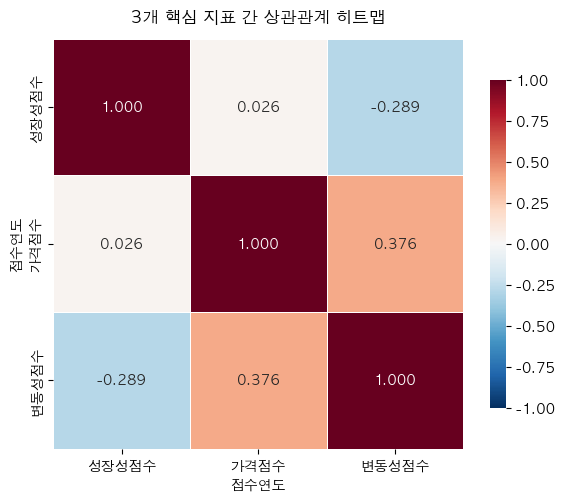

최대 상관계수 (절대값): 0.376
→ 세 지표가 충분히 독립적입니다. Z-score 합산이 유효합니다.


In [ ]:
# EDA: 3개 핵심 지표 간 상관관계 확인
# [의사결정 근거] 지표 간 상관이 너무 높으면 사실상 같은 정보를 두 번 쓰는 셈
# → 상관계수를 확인해 지표 독립성 검증

corr_df = gu_z_score[["성장성점수", "가격점수", "변동성점수"]].corr().round(3)
print("3개 지표 간 상관계수:")
print(corr_df.to_string())
print()

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.zeros_like(corr_df, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True  # 상삼각 숨기기

sns.heatmap(
    corr_df,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    square=True,
    cbar_kws={"shrink": 0.8}
)
ax.set_title("3개 핵심 지표 간 상관관계 히트맵", fontsize=12, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

# 해석 가이드
max_corr = corr_df.abs().where(~np.eye(len(corr_df), dtype=bool)).max().max()
print(f"최대 상관계수 (절대값): {max_corr:.3f}")
if max_corr < 0.5:
    print("→ 세 지표가 충분히 독립적입니다. Z-score 합산이 유효합니다.")
elif max_corr < 0.8:
    print("→ 중간 수준의 상관 존재. 결과 해석 시 참고 필요합니다.")
else:
    print("→ 높은 상관 존재. 두 지표가 비슷한 정보를 담고 있을 수 있습니다.")

In [46]:
# 최종 점수 — 안전형 / 중립형 / 공격형
# [가중치 설계 근거]
# 안전형: 변동성 최우선(1.5) → 가격 급등락 없는 안정 지역 선호
# 중립형: 균등(1.0) → 세 지표를 균형 있게 고려
# 공격형: 성장성 최우선(1.5) → 단기 고수익 가능성 있는 고성장 지역 선호
# ※ 모든 가중치 합 = 3.0 → 성향 간 점수 스케일 공정 비교 가능

# 안전형
gu_z_score["안전형점수 구"] = (0.5 * gu_z_score["성장성점수"] + 1.0 * gu_z_score["가격점수"] + 1.5 * gu_z_score["변동성점수"])

# 중립형
gu_z_score["중립형점수 구"] = (1.0 * gu_z_score["성장성점수"] + 1.0 * gu_z_score["가격점수"] + 1.0 * gu_z_score["변동성점수"])

# 공격형
gu_z_score["공격형점수 구"] = (1.5 * gu_z_score["성장성점수"] + 1.0 * gu_z_score["가격점수"] + 0.5 * gu_z_score["변동성점수"])

safe_rank_gu = gu_z_score.sort_values("안전형점수 구", ascending=False).reset_index(drop=True)
neutral_rank_gu = gu_z_score.sort_values("중립형점수 구", ascending=False).reset_index(drop=True)
aggr_rank_gu = gu_z_score.sort_values("공격형점수 구", ascending=False).reset_index(drop=True)

In [48]:
# 결과 확인
print("=== 안전형 TOP3 ===")
print(safe_rank_gu[["자치구명","안전형점수 구","성장성점수","가격점수","변동성점수"]].head(3).to_string(index=False))

print("\n=== 중립형 TOP3 ===")
print(neutral_rank_gu[["자치구명","중립형점수 구","성장성점수","가격점수","변동성점수"]].head(3).to_string(index=False))

print("\n=== 공격형 TOP3 ===")
print(aggr_rank_gu[["자치구명","공격형점수 구","성장성점수","가격점수","변동성점수"]].head(3).to_string(index=False))

=== 안전형 TOP3 ===
자치구명  안전형점수 구   성장성점수   가격점수  변동성점수
 중랑구  3.01900  1.0419 0.8662 1.0879
 도봉구  2.49390 -1.0852 1.6241 0.9416
 관악구  2.48295 -0.8162 0.9571 1.2893

=== 중립형 TOP3 ===
자치구명  중립형점수 구  성장성점수   가격점수  변동성점수
 중랑구   2.9960 1.0419 0.8662 1.0879
 금천구   2.7901 1.2435 0.9270 0.6196
 은평구   1.8658 0.1905 0.9052 0.7701

=== 공격형 TOP3 ===
자치구명  공격형점수 구  성장성점수    가격점수  변동성점수
 금천구  3.10205 1.2435  0.9270 0.6196
 중랑구  2.97300 1.0419  0.8662 1.0879
서대문구  1.77970 1.0217 -0.0049 0.5041


## 가중치 민감도 분석 (Sensitivity Analysis)
가중치를 바꿔도 결과가 안정적인지 검증합니다.

In [53]:
# 가중치 민감도 분석 (Sensitivity Analysis)
# [의사결정 근거] 가중치 선택이 결과에 얼마나 영향을 미치는지 검증합니다.
# "가중치를 조금 바꿔도 TOP3가 안정적이다" → 결과가 robust(신뢰 가능)
# "가중치에 따라 TOP3가 크게 달라진다" → 투자자가 직접 조정해야 한다는 의미

# 테스트할 가중치 시나리오 (성장성, 가격, 변동성)
weight_scenarios = {
    "안전형 기본 (0.5/1.0/1.5)":  (0.5, 1.0, 1.5),
    "안전형 변형1 (0.3/1.0/1.7)": (0.3, 1.0, 1.7),
    "안전형 변형2 (0.7/1.0/1.3)": (0.7, 1.0, 1.3),
    "중립형 기본 (1.0/1.0/1.0)":  (1.0, 1.0, 1.0),
    "공격형 기본 (1.5/1.0/0.5)":  (1.5, 1.0, 0.5),
    "공격형 변형1 (1.7/1.0/0.3)": (1.7, 1.0, 0.3),
    "공격형 변형2 (1.3/1.0/0.7)": (1.3, 1.0, 0.7),
}

print(" 가중치 시나리오별 TOP3 자치구 비교")
print("-" * 65)

results = {}
for scenario_name, (w_g, w_p, w_v) in weight_scenarios.items():
    temp = gu_z_score.copy()
    temp["시나리오점수"] = (
        w_g * temp["성장성점수"] +
        w_p * temp["가격점수"] +
        w_v * temp["변동성점수"]
    )
    top3 = temp.sort_values("시나리오점수", ascending=False).head(3)["자치구명"].tolist()
    results[scenario_name] = top3
    print(f"{scenario_name}")
    print(f"  TOP3: {top3[0]}, {top3[1]}, {top3[2]}")
    print()

 가중치 시나리오별 TOP3 자치구 비교
-----------------------------------------------------------------
안전형 기본 (0.5/1.0/1.5)
  TOP3: 중랑구, 도봉구, 관악구

안전형 변형1 (0.3/1.0/1.7)
  TOP3: 중랑구, 관악구, 도봉구

안전형 변형2 (0.7/1.0/1.3)
  TOP3: 중랑구, 금천구, 강북구

중립형 기본 (1.0/1.0/1.0)
  TOP3: 중랑구, 금천구, 은평구

공격형 기본 (1.5/1.0/0.5)
  TOP3: 금천구, 중랑구, 서대문구

공격형 변형1 (1.7/1.0/0.3)
  TOP3: 금천구, 중랑구, 성북구

공격형 변형2 (1.3/1.0/0.7)
  TOP3: 중랑구, 금천구, 은평구



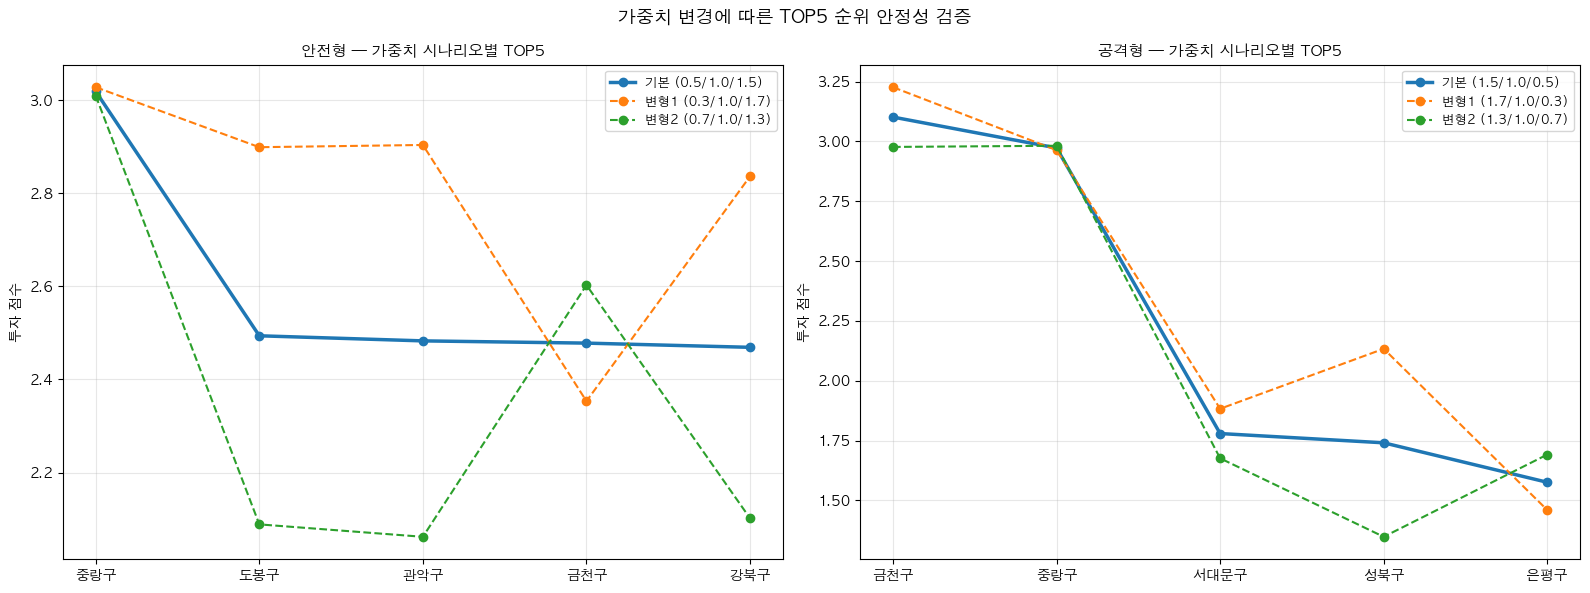

In [55]:
# 민감도 분석 시각화
# 안전형 / 공격형 각각 기본 + 변형 시나리오의 TOP5 점수 비교

safe_scenarios = {
    "기본 (0.5/1.0/1.5)":  (0.5, 1.0, 1.5),
    "변형1 (0.3/1.0/1.7)": (0.3, 1.0, 1.7),
    "변형2 (0.7/1.0/1.3)": (0.7, 1.0, 1.3),
}
aggr_scenarios = {
    "기본 (1.5/1.0/0.5)":  (1.5, 1.0, 0.5),
    "변형1 (1.7/1.0/0.3)": (1.7, 1.0, 0.3),
    "변형2 (1.3/1.0/0.7)": (1.3, 1.0, 0.7),
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("가중치 변경에 따른 TOP5 순위 안정성 검증", fontsize=13, fontweight="bold")

colors_line = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for ax, scenarios, title in [
    (axes[0], safe_scenarios, "안전형 — 가중치 시나리오별 TOP5"),
    (axes[1], aggr_scenarios, "공격형 — 가중치 시나리오별 TOP5"),
]:
    # 기본 시나리오 TOP5 자치구 기준으로 고정
    base_w = list(scenarios.values())[0]
    temp_base = gu_z_score.copy()
    temp_base["점수"] = (base_w[0] * temp_base["성장성점수"] + base_w[1] * temp_base["가격점수"] + base_w[2] * temp_base["변동성점수"])
    top5_gu = temp_base.sort_values("점수", ascending=False).head(5)["자치구명"].tolist()

    x = range(len(top5_gu))
    for idx, (sname, (wg, wp, wv)) in enumerate(scenarios.items()):
        temp = gu_z_score.copy()
        temp["점수"] = wg * temp["성장성점수"] + wp * temp["가격점수"] + wv * temp["변동성점수"]
        scores = temp[temp["자치구명"].isin(top5_gu)].set_index("자치구명").loc[top5_gu]["점수"]
        lw = 2.5 if idx == 0 else 1.5
        ls = "-" if idx == 0 else "--"
        ax.plot(x, scores.values, marker="o", linewidth=lw, linestyle=ls,
                color=colors_line[idx], label=sname)

    ax.set_xticks(list(x))
    ax.set_xticklabels(top5_gu, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel("투자 점수")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 자치구별 투자 성향 분석 — 시각화

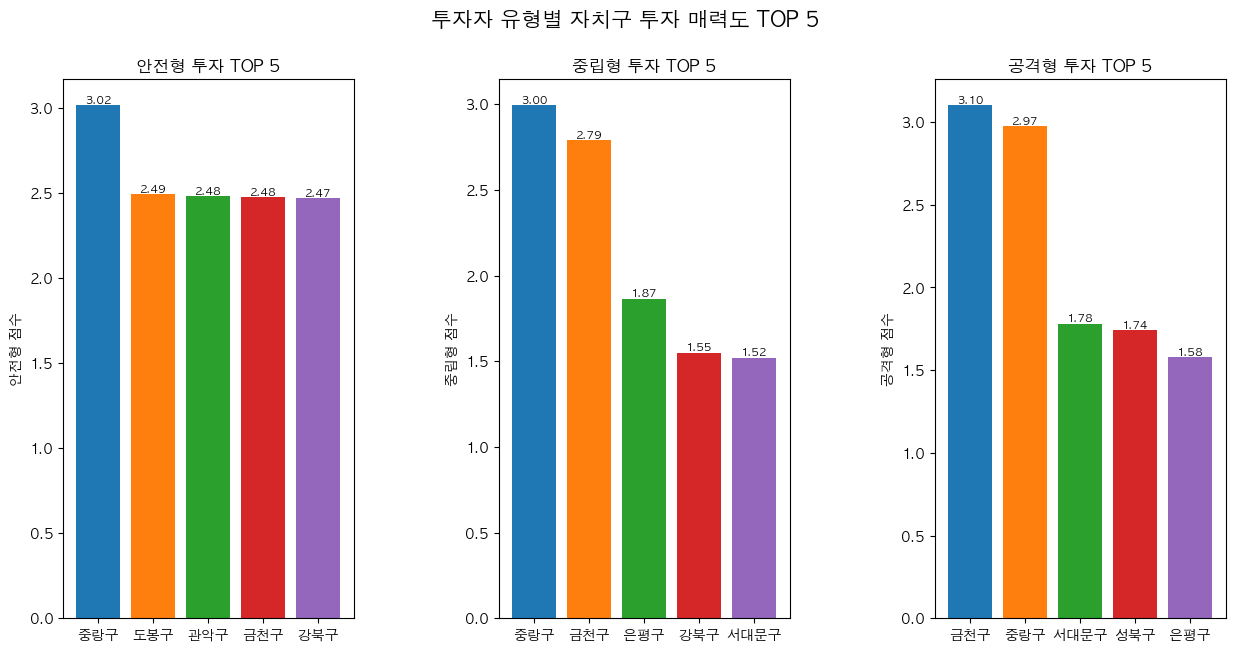

In [56]:
# 투자 성향에 따라 투자 유망 지역이 어떻게 달라지는지 시각화
safe_top5 = safe_rank_gu.head(5)[["자치구명", "안전형점수 구"]]
neutral_top5 = neutral_rank_gu.head(5)[["자치구명", "중립형점수 구"]]
aggr_top5 = aggr_rank_gu.head(5)[["자치구명", "공격형점수 구"]]

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]

fig, axes = plt.subplots(1, 3, figsize=(15, 7))
fig.suptitle("투자자 유형별 자치구 투자 매력도 TOP 5", fontsize=15)
fig.subplots_adjust(wspace=0.5)

x = axes[0]
x.bar(range(len(safe_top5)), safe_top5["안전형점수 구"], color=colors[:len(safe_top5)])
x.set_title("안전형 투자 TOP 5")
x.set_xticks(range(len(safe_top5)))
x.set_xticklabels(safe_top5["자치구명"])
x.set_ylabel("안전형 점수")
for i, v in enumerate(safe_top5["안전형점수 구"]):
    x.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

x1 = axes[1]
x1.bar(range(len(neutral_top5)), neutral_top5["중립형점수 구"], color=colors[:len(neutral_top5)])
x1.set_title("중립형 투자 TOP 5")
x1.set_xticks(range(len(neutral_top5)))
x1.set_xticklabels(neutral_top5["자치구명"])
x1.set_ylabel("중립형 점수")
for i, v in enumerate(neutral_top5["중립형점수 구"]):
    x1.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

x2 = axes[2]
x2.bar(range(len(aggr_top5)), aggr_top5["공격형점수 구"], color=colors[:len(aggr_top5)])
x2.set_title("공격형 투자 TOP 5")
x2.set_xticks(range(len(aggr_top5)))
x2.set_xticklabels(aggr_top5["자치구명"])
x2.set_ylabel("공격형 점수")
for i, v in enumerate(aggr_top5["공격형점수 구"]):
    x2.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

plt.show()

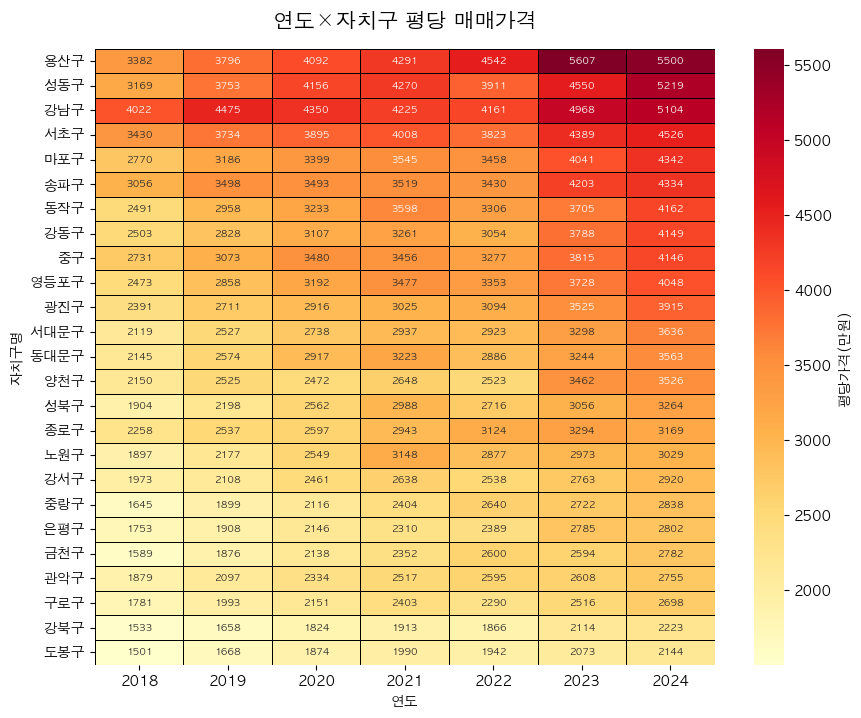

In [26]:
# 연도 × 자치구 평당가 히트맵
latest_year = max(years)
df3_1 = price_diff_gu_year.copy()
df3_1 = df3_1.sort_values(latest_year, ascending=False)
df3_1 = df3_1.set_index("자치구명")[years]

plt.figure(figsize=(10, 8))
sns.heatmap(df3_1, cmap="YlOrRd", linewidths=0.5, linecolor="black",
            cbar_kws={"label": "평당가격(만원)"}, annot=True, annot_kws={"fontsize": 7}, fmt=".0f")
plt.title("연도×자치구 평당 매매가격", pad=16, fontsize=15, fontweight="bold")
plt.xlabel("연도")
plt.ylabel("자치구명")
plt.show()

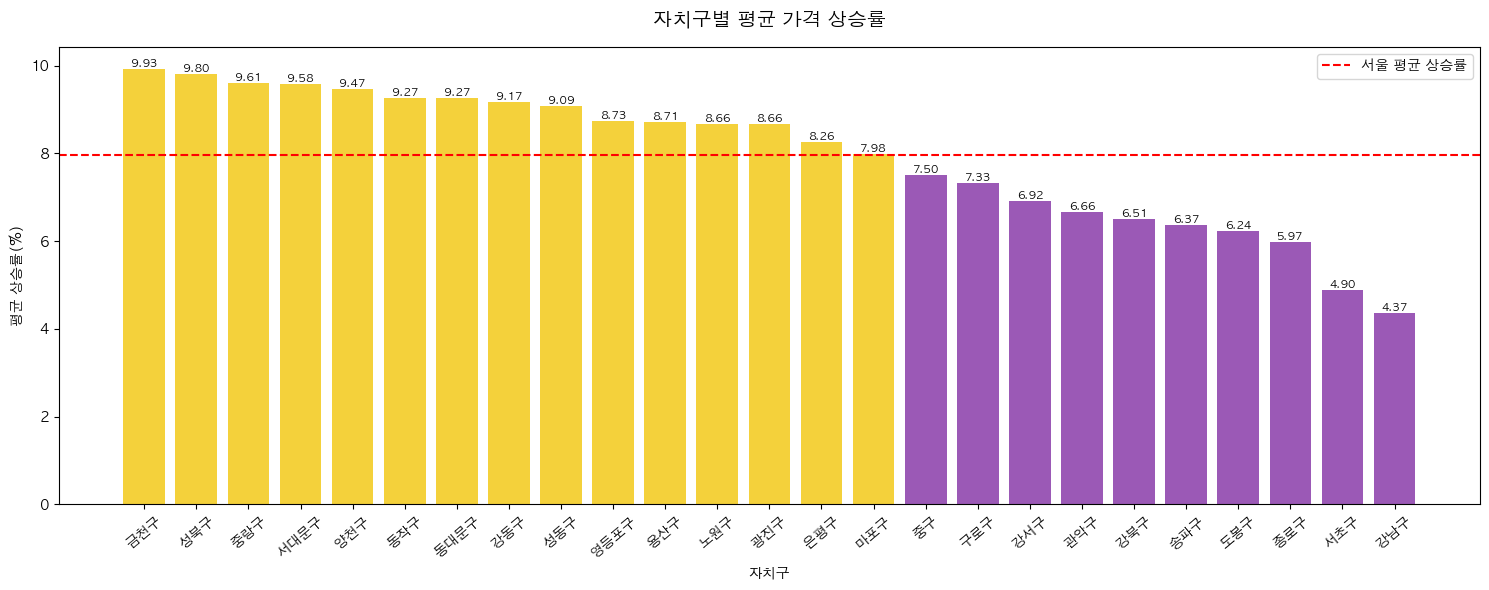

In [27]:
# 자치구별 평균 상승률 Bar chart
df3_2 = gu_growth_yearly_diff[["자치구명", "평균상승률(%)"]].copy()
df3_2 = df3_2.sort_values("평균상승률(%)", ascending=False).reset_index(drop=True)
seoul_avg_growth = df3_2["평균상승률(%)"].mean()

colors = ["#F4D13B" if g >= seoul_avg_growth else "#9b59b6" for g in df3_2["평균상승률(%)"]]

plt.figure(figsize=(15, 6))
plt.bar(range(len(df3_2)), df3_2["평균상승률(%)"], color=colors)
plt.xticks(range(len(df3_2)), df3_2["자치구명"], rotation=40)
plt.title("자치구별 평균 가격 상승률", pad=15, fontsize=14, fontweight="bold")
plt.xlabel("자치구")
plt.ylabel("평균 상승률(%)")
plt.axhline(y=seoul_avg_growth, color="red", linestyle="--", linewidth=1.5, label="서울 평균 상승률")
plt.legend(loc="upper right")
plt.tight_layout()
for i, v in enumerate(df3_2["평균상승률(%)"]):
    plt.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)
plt.show()

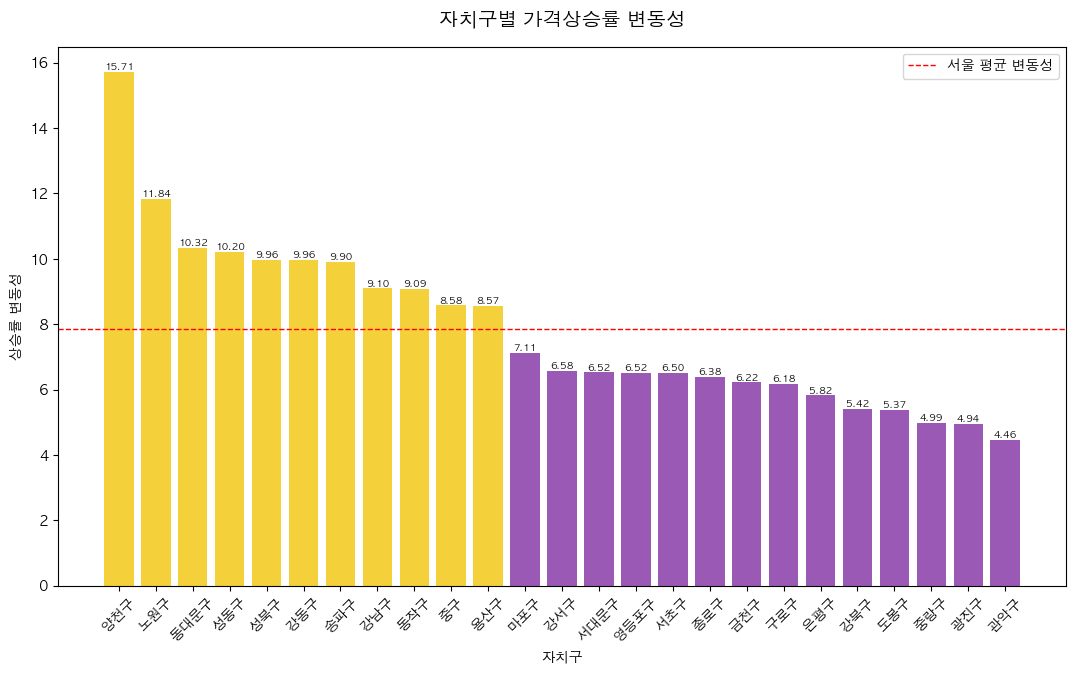

In [28]:
# 자치구별 상승률 변동성(표준편차) Bar chart
df3_3 = gu_growth_yearly_diff[["자치구명", "상승률변동성"]].copy()
df3_3 = df3_3.sort_values("상승률변동성", ascending=False).reset_index(drop=True)
seoul_avg_vol = df3_3["상승률변동성"].mean()

colors = ["#9b59b6" if v <= seoul_avg_vol else "#F4D13B" for v in df3_3["상승률변동성"]]

plt.figure(figsize=(13, 7))
plt.bar(range(len(df3_3)), df3_3["상승률변동성"], color=colors)
plt.xticks(range(len(df3_3)), df3_3["자치구명"], rotation=45)
plt.title("자치구별 가격상승률 변동성", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("자치구")
plt.ylabel("상승률 변동성")
plt.axhline(seoul_avg_vol, color="red", linestyle="--", linewidth=1, label="서울 평균 변동성")
plt.legend(loc="upper right")
for i, v in enumerate(df3_3["상승률변동성"]):
    plt.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=7)
plt.show()

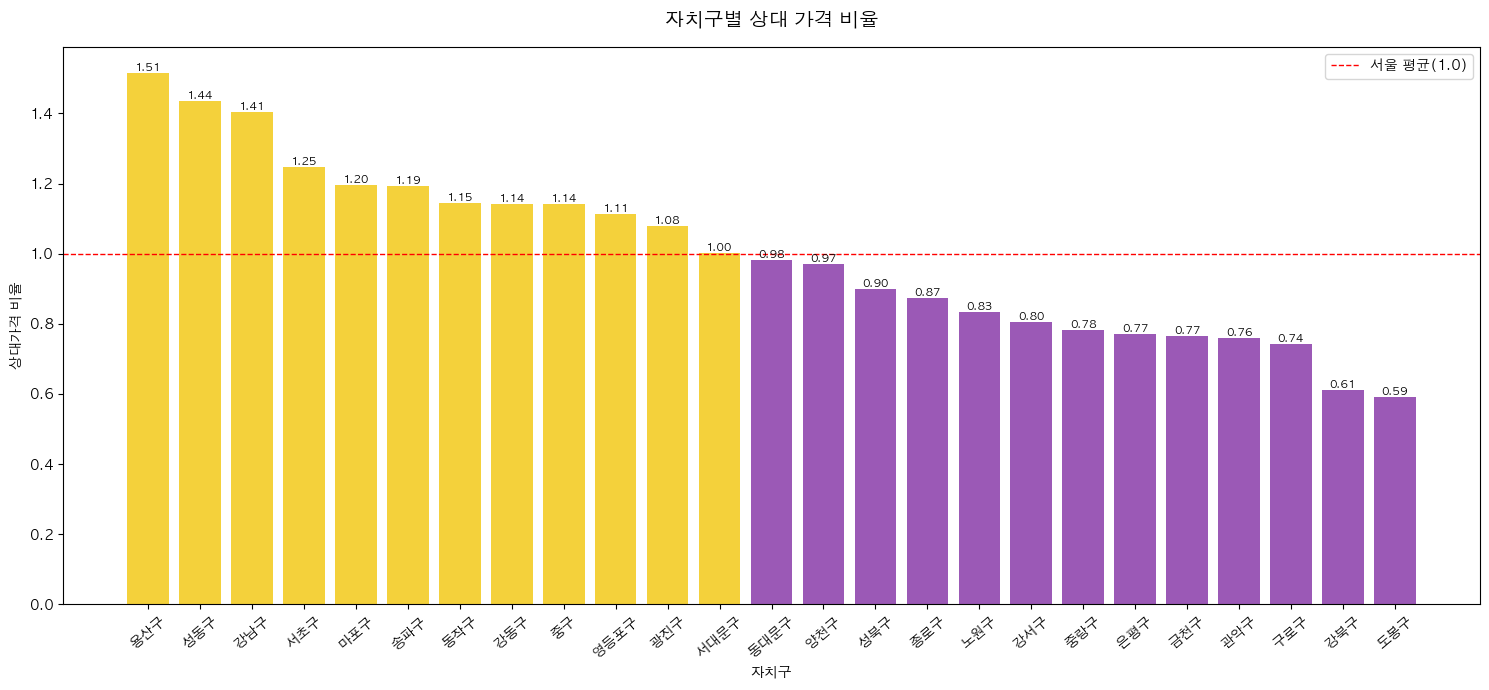

In [29]:
# 자치구 상대가격비율 Bar chart
df3_4 = gu_growth_yearly_diff[["자치구명", "상대적가격비율"]].copy()
df3_4 = df3_4.sort_values("상대적가격비율", ascending=False).reset_index(drop=True)

colors = ["#F4D13B" if ratio > 1 else "#9b59b6" for ratio in df3_4["상대적가격비율"]]

plt.figure(figsize=(15, 7))
plt.bar(range(len(df3_4)), df3_4["상대적가격비율"], color=colors)
plt.xticks(range(len(df3_4)), df3_4["자치구명"], rotation=40)
plt.title("자치구별 상대 가격 비율", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("자치구")
plt.ylabel("상대가격 비율")
plt.axhline(1, color="red", linestyle="--", linewidth=1, label="서울 평균(1.0)")
plt.legend(loc="upper right")
plt.tight_layout()
for i, v in enumerate(df3_4["상대적가격비율"]):
    plt.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)
plt.show()

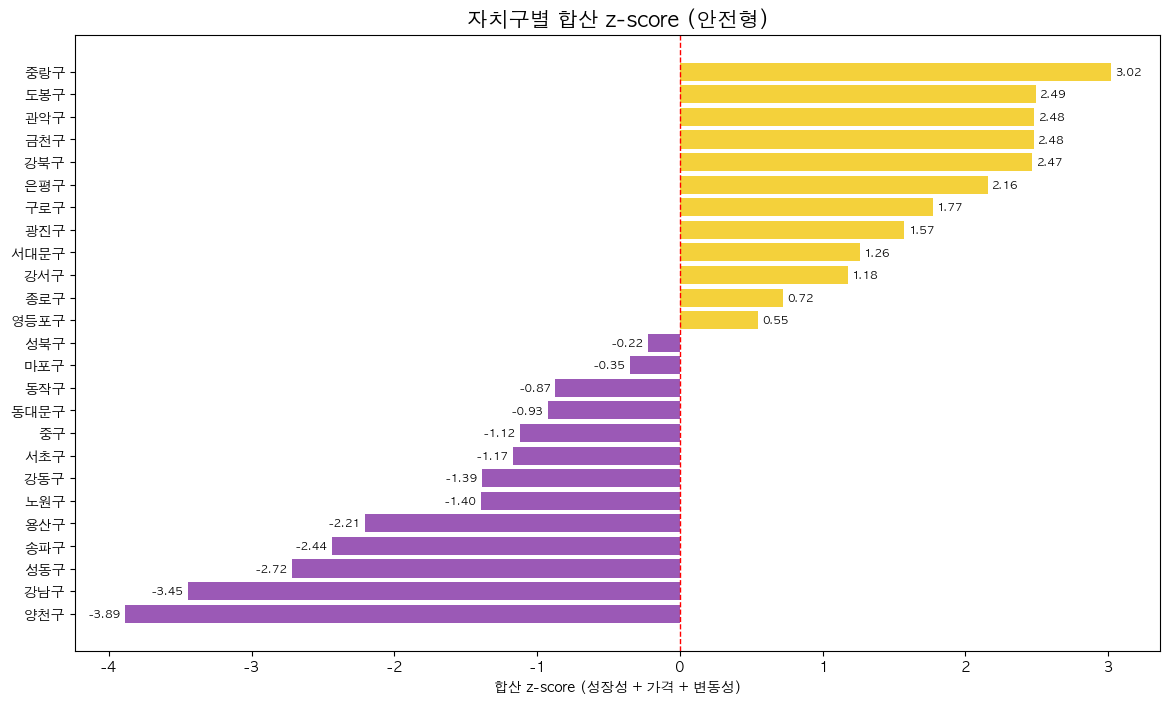

In [30]:
# 안전형 투자자가 선호하는 구 → z-score 총합
df_safe = gu_z_score[["자치구명", "안전형점수 구"]].copy()
df_safe = df_safe.sort_values("안전형점수 구", ascending=True).reset_index(drop=True)
colors = ["#F4D13B" if v >= 0 else "#9b59b6" for v in df_safe["안전형점수 구"]]

plt.figure(figsize=(14, 8))
plt.barh(range(len(df_safe)), df_safe["안전형점수 구"], color=colors)
plt.yticks(range(len(df_safe)), df_safe["자치구명"])
plt.title("자치구별 합산 z-score (안전형)", fontsize=15, fontweight="bold")
plt.xlabel("합산 z-score (성장성 + 가격 + 변동성)")
plt.axvline(0, color="red", linestyle="--", linewidth=1)
for i, v in enumerate(df_safe["안전형점수 구"]):
    x_pos = v + 0.03 if v >= 0 else v - 0.03
    ha = "left" if v >= 0 else "right"
    plt.text(x_pos, i, f"{v:.2f}", va="center", ha=ha, fontsize=8)
plt.show()

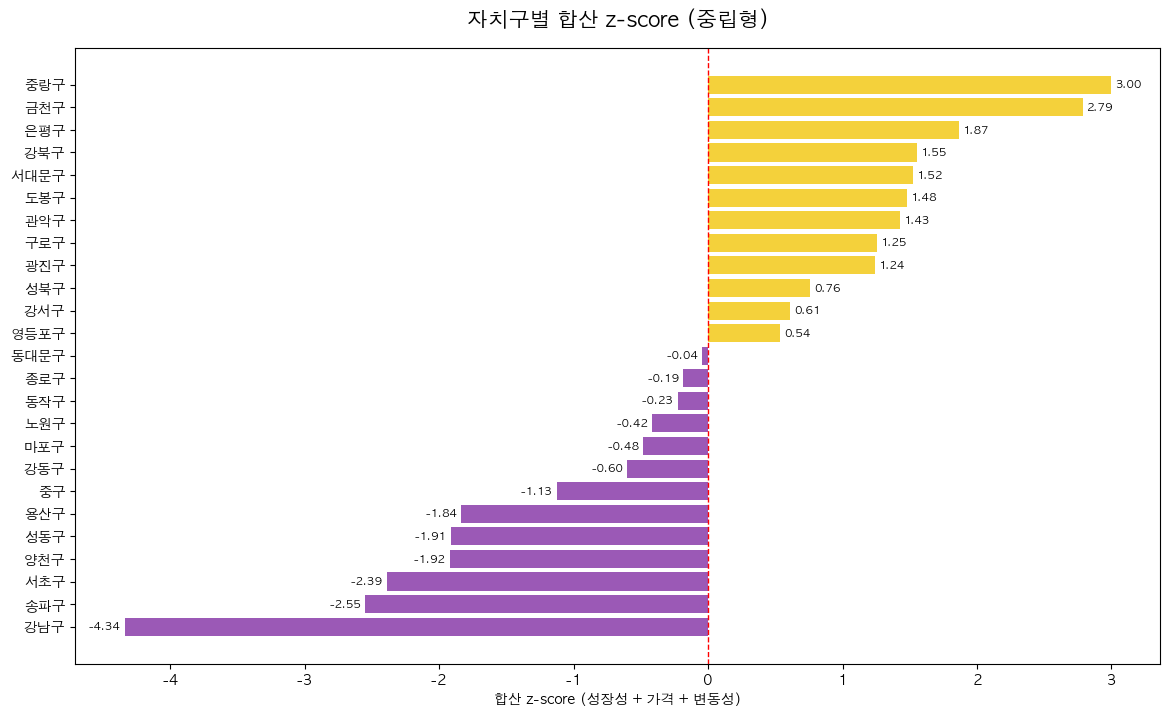

In [31]:
# 중립형 투자자들이 선호하는 구 → z-score 총합
df_mid = gu_z_score[["자치구명", "중립형점수 구"]].copy()
df_mid = df_mid.sort_values("중립형점수 구").reset_index(drop=True)
colors = ["#F4D13B" if v >= 0 else "#9b59b6" for v in df_mid["중립형점수 구"]]

plt.figure(figsize=(14, 8))
plt.barh(range(len(df_mid)), df_mid["중립형점수 구"], color=colors)
plt.yticks(range(len(df_mid)), df_mid["자치구명"])
plt.title("자치구별 합산 z-score (중립형)", fontsize=15, fontweight="bold", pad=15)
plt.xlabel("합산 z-score (성장성 + 가격 + 변동성)")
plt.axvline(0, color="red", linestyle="--", linewidth=1)
for i, v in enumerate(df_mid["중립형점수 구"]):
    x_pos = v + 0.03 if v >= 0 else v - 0.03
    ha = "left" if v >= 0 else "right"
    plt.text(x_pos, i, f"{v:.2f}", va="center", ha=ha, fontsize=8)
plt.show()

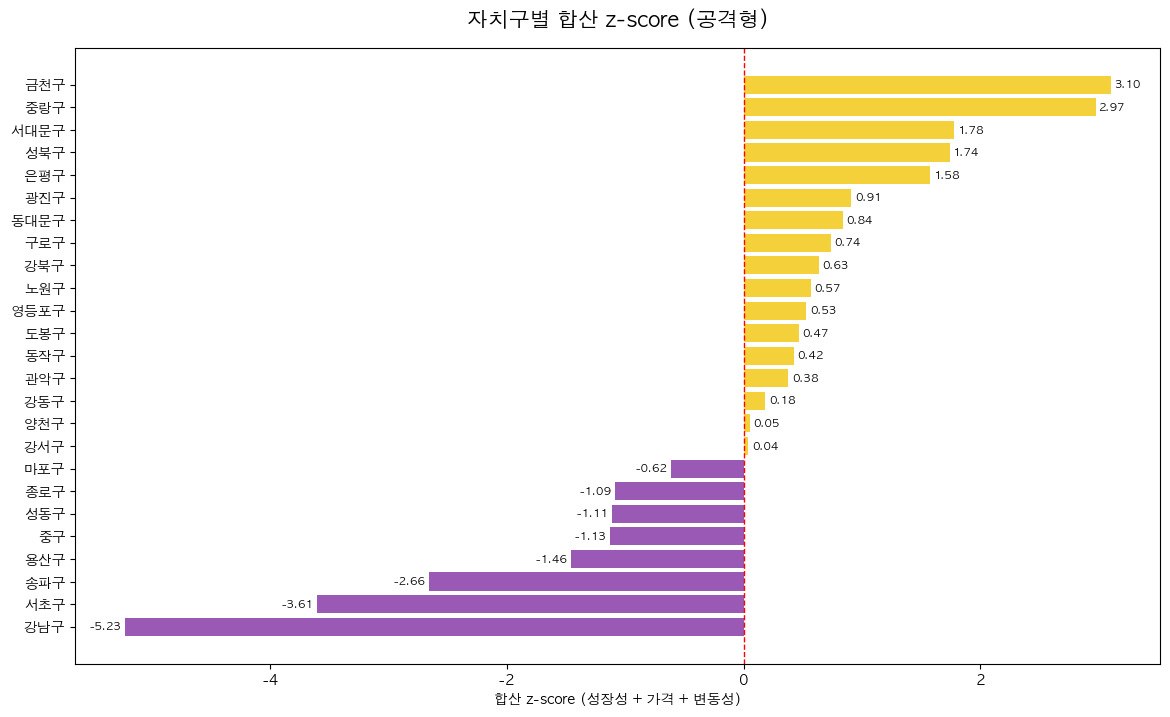

In [32]:
# 공격형 투자자들이 선호하는 구 → z-score 총합
df_aggr = gu_z_score[["자치구명", "공격형점수 구"]].copy()
df_aggr = df_aggr.sort_values("공격형점수 구").reset_index(drop=True)
colors = ["#F4D13B" if v >= 0 else "#9b59b6" for v in df_aggr["공격형점수 구"]]

plt.figure(figsize=(14, 8))
plt.barh(range(len(df_aggr)), df_aggr["공격형점수 구"], color=colors)
plt.yticks(range(len(df_aggr)), df_aggr["자치구명"])
plt.title("자치구별 합산 z-score (공격형)", fontsize=15, fontweight="bold", pad=15)
plt.xlabel("합산 z-score (성장성 + 가격 + 변동성)")
plt.axvline(0, color="red", linestyle="--", linewidth=1)
for i, v in enumerate(df_aggr["공격형점수 구"]):
    x_pos = v + 0.03 if v >= 0 else v - 0.03
    ha = "left" if v >= 0 else "right"
    plt.text(x_pos, i, f"{v:.2f}", va="center", ha=ha, fontsize=8)
plt.show()

## 건물유형별 세부 분석

In [33]:
# 안전형 투자자가 투자할 TOP3 자치구
top3_safe_gu = safe_rank_gu.head(3)[["자치구명", "안전형점수 구"]]
top3_safe_gu_list = top3_safe_gu["자치구명"].tolist()
print(top3_safe_gu)

접수연도 자치구명  안전형점수 구
0     중랑구  3.01900
1     도봉구  2.49390
2     관악구  2.48295


In [34]:
# TOP3 자치구 내 건물용도 확인 및 자치구 × 건물용도 × 연도 분석 (안전형)
df_safe_top_gu = df_all[df_all["자치구명"].isin(top3_safe_gu_list)].copy()
print("안전형 TOP3 자치구 데이터 크기:", df_safe_top_gu.shape)
print("건물용도 분포:")
print(df_safe_top_gu["건물용도"].value_counts())

safe_gu_safe_price = df_safe_top_gu.pivot_table(
    index=["자치구명", "건물용도"], columns="접수연도", values="평당가격", aggfunc="mean"
).reset_index()
print(safe_gu_safe_price)

안전형 TOP3 자치구 데이터 크기: (89803, 25)
건물용도 분포:
건물용도
아파트      40406
연립다세대    37060
단독다가구     7274
오피스텔      5063
Name: count, dtype: int64
접수연도 자치구명   건물용도         2018         2019         2020         2021  \
0     관악구  단독다가구  1663.655908  1786.858786  1986.211078  1995.319971   
1     관악구    아파트  2108.614987  2484.796027  2837.816644  3592.815504   
2     관악구  연립다세대  1646.589356  1757.634865  1869.676455  2034.482574   
3     관악구   오피스텔  2013.970979  2133.798207  2167.712075  2366.032548   
4     도봉구  단독다가구  1158.207780  1382.853036  1376.297485  1458.841941   
5     도봉구    아파트  1661.983712  1925.305375  2205.173609  2955.282021   
6     도봉구  연립다세대  1135.527567  1239.302127  1298.560417  1490.457648   
7     도봉구   오피스텔  1412.726222  1625.181199  1699.366615  2279.771182   
8     중랑구  단독다가구  1341.853572  1470.318130  1493.815832  1697.353049   
9     중랑구    아파트  1776.742318  2167.951853  2471.336904  3183.522645   
10    중랑구  연립다세대  1571.201675  1673.232820  1886.685316  2149.317961   
11 

In [35]:
# 연도별 건물용도별 평당가격 상승률 (안전형)
safe_gu_growth = safe_gu_safe_price.copy()

for i in range(1, len(years)):
    pre_y = years[i-1]
    cur_y = years[i]
    col_name = f"{pre_y}->{cur_y} 상승률(%)"
    safe_gu_growth[col_name] = (
        (safe_gu_growth[cur_y] - safe_gu_growth[pre_y]) / safe_gu_growth[pre_y] * 100
    )

growth_cols_use_safe = [c for c in safe_gu_growth.columns if "상승률(%)" in str(c)]
safe_gu_growth["평균상승률(%)"] = safe_gu_growth[growth_cols_use_safe].mean(axis=1)
safe_gu_growth["상승률변동성"] = safe_gu_growth[growth_cols_use_safe].std(axis=1)
safe_gu_growth["현재평당가격"] = safe_gu_growth[years[-1]]

print(safe_gu_growth[["자치구명", "건물용도", "평균상승률(%)", "상승률변동성", "현재평당가격"]])

접수연도 자치구명   건물용도   평균상승률(%)     상승률변동성       현재평당가격
0     관악구  단독다가구   3.580054   5.789078  2038.440905
1     관악구    아파트   8.934530  13.546129  3386.770523
2     관악구  연립다세대   4.697276   7.880702  2137.849486
3     관악구   오피스텔   3.623544  12.268139  2404.437669
4     도봉구  단독다가구   2.692204  13.700384  1298.623517
5     도봉구    아파트   8.800228  16.324929  2606.213108
6     도봉구  연립다세대   5.610283   8.560731  1548.462954
7     도봉구   오피스텔   2.733808  19.618700  1521.020617
8     중랑구  단독다가구   1.071897  10.976834  1387.742190
9     중랑구    아파트  10.046343  13.982120  3030.369296
10    중랑구  연립다세대   9.871810   6.981266  2736.525227
11    중랑구   오피스텔  13.268676  20.782882  2836.604392


In [ ]:
# Z-score 계산 및 최종 점수 산출 (안전형)
safe_gu_z_score = safe_gu_growth.copy()

mean_growth_s = safe_gu_z_score["평균상승률(%)"].mean()
std_growth_s = safe_gu_z_score["평균상승률(%)"].std()
mean_price_s = safe_gu_z_score["현재평당가격"].mean()
std_price_s = safe_gu_z_score["현재평당가격"].std()
mean_vol_s = safe_gu_z_score["상승률변동성"].mean()
std_vol_s = safe_gu_z_score["상승률변동성"].std()

safe_gu_z_score["성장성s_z_score"] = (safe_gu_z_score["평균상승률(%)"] - mean_growth_s) / std_growth_s
safe_gu_z_score["가격s_z_score"] = (safe_gu_z_score["현재평당가격"]   - mean_price_s)  / std_price_s
safe_gu_z_score["변동성s_z_score"] = (safe_gu_z_score["상승률변동성"]   - mean_vol_s)    / std_vol_s

safe_gu_z_score["s성장성_z_score"] = safe_gu_z_score["성장성s_z_score"]
safe_gu_z_score["s가격_z_score"] = -safe_gu_z_score["가격s_z_score"]
safe_gu_z_score["s변동성_z_score"] = -safe_gu_z_score["변동성s_z_score"]

safe_gu_z_score["안전형투자건물점수"] = (
    0.5 * safe_gu_z_score["s성장성_z_score"] +
    1.0 * safe_gu_z_score["s가격_z_score"] +
    1.5 * safe_gu_z_score["s변동성_z_score"]
)

safe_gu_rank = safe_gu_z_score.sort_values("안전형투자건물점수", ascending=False).reset_index(drop=True)
print(safe_gu_rank[["자치구명","건물용도","안전형투자건물점수","평균상승률(%)","상승률변동성","현재평당가격"]].to_string(index=False))

자치구명  건물용도  안전형투자건물점수  평균상승률(%)    상승률변동성      현재평당가격
 도봉구 연립다세대   2.155468  5.610283  8.560731 1548.462954
 관악구 단독다가구   2.053111  3.580054  5.789078 2038.440905
 중랑구 연립다세대   1.507586  9.871810  6.981266 2736.525227
 관악구 연립다세대   1.403827  4.697276  7.880702 2137.849486
 중랑구 단독다가구   1.033994  1.071897 10.976834 1387.742190
 도봉구 단독다가구   0.523351  2.692204 13.700384 1298.623517
 관악구  오피스텔  -0.490449  3.623544 12.268139 2404.437669
 중랑구   아파트  -1.078494 10.046343 13.982120 3030.369296
 도봉구   아파트  -1.367012  8.800228 16.324929 2606.213108
 관악구   아파트  -1.598834  8.934530 13.546129 3386.770523
 도봉구  오피스텔  -1.639515  2.733808 19.618700 1521.020617
 중랑구  오피스텔  -2.503034 13.268676 20.782882 2836.604392


In [ ]:
# 중립형 투자자 분석
top3_neutral_gu = neutral_rank_gu.head(3)[["자치구명", "중립형점수 구"]]
top3_neutral_gu_list = top3_neutral_gu["자치구명"].tolist()
print(top3_neutral_gu)

df_neutral_top_gu = df_all[df_all["자치구명"].isin(top3_neutral_gu_list)].copy()

neutral_gu_safe_price = df_neutral_top_gu.pivot_table(
    index=["자치구명", "건물용도"], columns="접수연도", values="평당가격", aggfunc="mean"
).reset_index()

neutral_gu_growth = neutral_gu_safe_price.copy()
for i in range(1, len(years)):
    pre_y, cur_y = years[i-1], years[i]
    col_name = f"{pre_y}->{cur_y} 상승률(%)"
    neutral_gu_growth[col_name] = (
        (neutral_gu_growth[cur_y] - neutral_gu_growth[pre_y]) / neutral_gu_growth[pre_y] * 100
    )

growth_cols_use_neutral = [c for c in neutral_gu_growth.columns if "상승률(%)" in str(c)]
neutral_gu_growth["평균상승률(%)"] = neutral_gu_growth[growth_cols_use_neutral].mean(axis=1)
neutral_gu_growth["상승률변동성"] = neutral_gu_growth[growth_cols_use_neutral].std(axis=1)
neutral_gu_growth["현재평당가격"] = neutral_gu_growth[years[-1]]

neutral_gu_z_score = neutral_gu_growth.copy()
mean_growth_n = neutral_gu_z_score["평균상승률(%)"].mean()
std_growth_n = neutral_gu_z_score["평균상승률(%)"].std()
mean_price_n = neutral_gu_z_score["현재평당가격"].mean()
std_price_n = neutral_gu_z_score["현재평당가격"].std()
mean_vol_n = neutral_gu_z_score["상승률변동성"].mean()
std_vol_n = neutral_gu_z_score["상승률변동성"].std()

neutral_gu_z_score["성장성n_z_score"] = (neutral_gu_z_score["평균상승률(%)"] - mean_growth_n) / std_growth_n
neutral_gu_z_score["가격n_z_score"] = (neutral_gu_z_score["현재평당가격"] - mean_price_n) / std_price_n
neutral_gu_z_score["변동성n_z_score"] = (neutral_gu_z_score["상승률변동성"] - mean_vol_n) / std_vol_n

neutral_gu_z_score["n성장성_z_score"] = neutral_gu_z_score["성장성n_z_score"]
neutral_gu_z_score["n가격_z_score"] = -neutral_gu_z_score["가격n_z_score"]
neutral_gu_z_score["n변동성_z_score"] = -neutral_gu_z_score["변동성n_z_score"]

neutral_gu_z_score["중립형투자건물점수"] = (
    1.0 * neutral_gu_z_score["n성장성_z_score"] +
    1.0 * neutral_gu_z_score["n가격_z_score"] +
    1.0 * neutral_gu_z_score["n변동성_z_score"]
)

neutral_gu_rank = neutral_gu_z_score.sort_values("중립형투자건물점수", ascending=False).reset_index(drop=True)
print(neutral_gu_rank[["자치구명","건물용도","중립형투자건물점수","평균상승률(%)","상승률변동성","현재평당가격"]].to_string(index=False))

접수연도 자치구명  중립형점수 구
0     중랑구   2.9960
1     금천구   2.7901
2     은평구   1.8658
자치구명  건물용도  중립형투자건물점수  평균상승률(%)    상승률변동성      현재평당가격
 은평구 연립다세대   1.521885  5.849286  5.398575 2137.855680
 금천구 연립다세대   1.268042  6.594257  6.538460 2246.192456
 중랑구 연립다세대   1.196390  9.871810  6.981266 2736.525227
 금천구 단독다가구   0.795862  2.591057  9.608156 1447.582388
 은평구 단독다가구   0.239786  2.496255  8.526395 2007.290737
 중랑구 단독다가구   0.227222  1.071897 10.976834 1387.742190
 금천구  오피스텔  -0.491840 11.915168 13.296936 3211.138327
 은평구   아파트  -0.658346 10.353970  9.804060 3663.598993
 금천구   아파트  -0.774687 10.952737 14.847470 3005.038638
 중랑구   아파트  -0.808225 10.046343 13.982120 3030.369296
 은평구  오피스텔  -1.105902  0.418796 12.202335 2030.732744
 중랑구  오피스텔  -1.410187 13.268676 20.782882 2836.604392


In [ ]:
# 공격형 투자자 분석
top3_aggr_gu = aggr_rank_gu.head(3)[["자치구명", "공격형점수 구"]]
top3_aggr_gu_list = top3_aggr_gu["자치구명"].tolist()
print(top3_aggr_gu)

df_aggr_top_gu = df_all[df_all["자치구명"].isin(top3_aggr_gu_list)].copy()

aggr_gu_safe_price = df_aggr_top_gu.pivot_table(
    index=["자치구명", "건물용도"], columns="접수연도", values="평당가격", aggfunc="mean"
).reset_index()

aggr_gu_growth = aggr_gu_safe_price.copy()
for i in range(1, len(years)):
    pre_y, cur_y = years[i-1], years[i]
    col_name = f"{pre_y}->{cur_y} 상승률(%)"
    aggr_gu_growth[col_name] = (
        (aggr_gu_growth[cur_y] - aggr_gu_growth[pre_y]) / aggr_gu_growth[pre_y] * 100
    )

growth_cols_use_aggr = [c for c in aggr_gu_growth.columns if "상승률(%)" in str(c)]
aggr_gu_growth["평균상승률(%)"] = aggr_gu_growth[growth_cols_use_aggr].mean(axis=1)
aggr_gu_growth["상승률변동성"] = aggr_gu_growth[growth_cols_use_aggr].std(axis=1)
aggr_gu_growth["현재평당가격"] = aggr_gu_growth[years[-1]]

aggr_gu_z_score = aggr_gu_growth.copy()
mean_growth_a = aggr_gu_z_score["평균상승률(%)"].mean()
std_growth_a = aggr_gu_z_score["평균상승률(%)"].std()
mean_price_a = aggr_gu_z_score["현재평당가격"].mean()
std_price_a = aggr_gu_z_score["현재평당가격"].std()
mean_vol_a = aggr_gu_z_score["상승률변동성"].mean()
std_vol_a = aggr_gu_z_score["상승률변동성"].std()

aggr_gu_z_score["성장성a_z_score"] = (aggr_gu_z_score["평균상승률(%)"] - mean_growth_a) / std_growth_a
aggr_gu_z_score["가격a_z_score"] = (aggr_gu_z_score["현재평당가격"] - mean_price_a) / std_price_a
aggr_gu_z_score["변동성a_z_score"] = (aggr_gu_z_score["상승률변동성"] - mean_vol_a) / std_vol_a

aggr_gu_z_score["a성장성_z_score"] = aggr_gu_z_score["성장성a_z_score"]
aggr_gu_z_score["a가격_z_score"] = -aggr_gu_z_score["가격a_z_score"]
aggr_gu_z_score["a변동성_z_score"] = -aggr_gu_z_score["변동성a_z_score"]

aggr_gu_z_score["공격형투자건물점수"] = (
    1.5 * aggr_gu_z_score["a성장성_z_score"] +
    1.0 * aggr_gu_z_score["a가격_z_score"] +
    0.5 * aggr_gu_z_score["a변동성_z_score"]
)

aggr_gu_rank = aggr_gu_z_score.sort_values("공격형투자건물점수", ascending=False).reset_index(drop=True)
print(aggr_gu_rank[["자치구명","건물용도","공격형투자건물점수","평균상승률(%)","상승률변동성","현재평당가격"]].to_string(index=False))

접수연도  자치구명  공격형점수 구
0      금천구  3.10205
1      중랑구  2.97300
2     서대문구  1.77970
자치구명  건물용도  공격형투자건물점수  평균상승률(%)    상승률변동성      현재평당가격
 중랑구 연립다세대   1.211246  9.871810  6.981266 2736.525227
 중랑구  오피스텔   0.821255 13.268676 20.782882 2836.604392
 금천구  오피스텔   0.710036 11.915168 13.296936 3211.138327
 금천구 연립다세대   0.539638  6.594257  6.538460 2246.192456
 금천구   아파트   0.389008 10.952737 14.847470 3005.038638
 중랑구   아파트   0.096359 10.046343 13.982120 3030.369296
서대문구 연립다세대  -0.335372  5.244283  9.328888 2247.582886
서대문구  오피스텔  -0.365163  8.603621  6.231014 3690.451667
서대문구 단독다가구  -0.457779  7.114339  8.505488 3050.043640
 금천구 단독다가구  -0.466411  2.591057  9.608156 1447.582388
서대문구   아파트  -0.975916 10.416910 12.331237 4200.196253
 중랑구 단독다가구  -1.166901  1.071897 10.976834 1387.742190


## 최종 결과

In [58]:
# 최종 결과 요약 테이블 — PPT 결과 슬라이드와 1:1 대응
def get_top3(rank_df, score_col):
    top = rank_df.head(3)
    return [f"{row['자치구명']} ({row['건물용도']})" for _, row in top.iterrows()]

summary_df = pd.DataFrame({
    "투자 유형":              ["안전형",           "중립형",           "공격형"],
    "가중치 (성장/가격/변동)": ["0.5 / 1.0 / 1.5", "1.0 / 1.0 / 1.0", "1.5 / 1.0 / 0.5"],
    "TOP 1": [get_top3(safe_gu_rank, "안전형투자건물점수")[0],
              get_top3(neutral_gu_rank, "중립형투자건물점수")[0],
              get_top3(aggr_gu_rank, "공격형투자건물점수")[0]],
    "TOP 2": [get_top3(safe_gu_rank, "안전형투자건물점수")[1],
              get_top3(neutral_gu_rank, "중립형투자건물점수")[1],
              get_top3(aggr_gu_rank, "공격형투자건물점수")[1]],
    "TOP 3": [get_top3(safe_gu_rank, "안전형투자건물점수")[2],
              get_top3(neutral_gu_rank, "중립형투자건물점수")[2],
              get_top3(aggr_gu_rank, "공격형투자건물점수")[2]],
})

print(" 투자 성향별 최종 추천 지역 & 건물유형 TOP3")
print("-" * 70)
print(summary_df.to_string(index=False))

 투자 성향별 최종 추천 지역 & 건물유형 TOP3
----------------------------------------------------------------------
투자 유형  가중치 (성장/가격/변동)       TOP 1       TOP 2       TOP 3
  안전형 0.5 / 1.0 / 1.5 도봉구 (연립다세대) 관악구 (단독다가구) 중랑구 (연립다세대)
  중립형 1.0 / 1.0 / 1.0 은평구 (연립다세대) 금천구 (연립다세대) 중랑구 (연립다세대)
  공격형 1.5 / 1.0 / 0.5 중랑구 (연립다세대)  중랑구 (오피스텔)  금천구 (오피스텔)


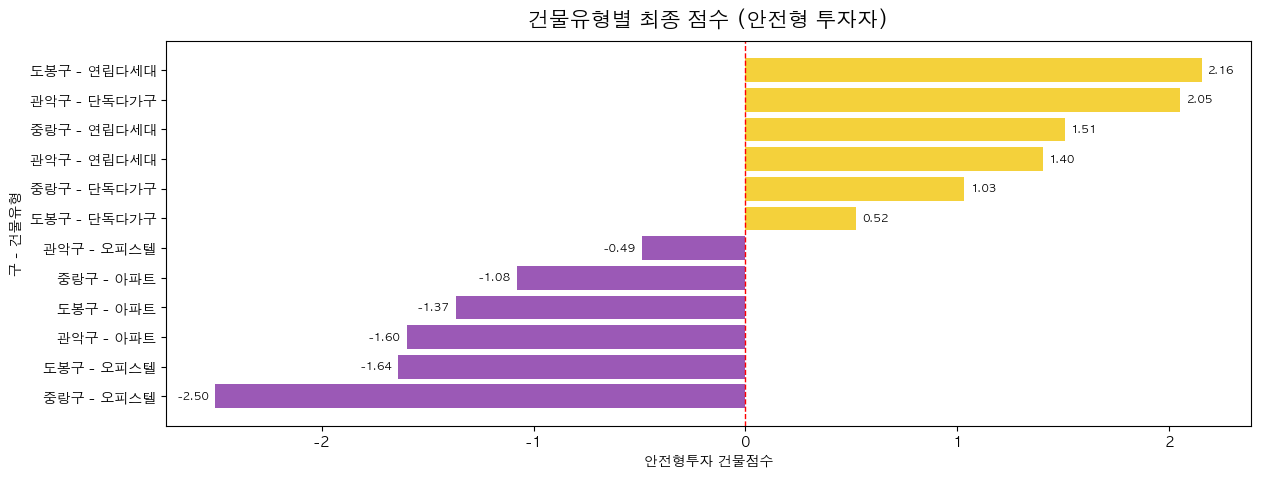

In [40]:
# 안전형 투자자 건물 유형별 최종 점수
df_safe_rank = safe_gu_rank[["자치구명", "건물용도", "안전형투자건물점수"]].copy()
df_safe_rank["라벨"] = df_safe_rank["자치구명"] + " - " + df_safe_rank["건물용도"]
df_safe_rank = df_safe_rank.sort_values("안전형투자건물점수", ascending=True).reset_index(drop=True)
colors = ["#F4D13B" if v >= 0 else "#9b59b6" for v in df_safe_rank["안전형투자건물점수"]]

plt.figure(figsize=(14, 5))
plt.barh(df_safe_rank["라벨"], df_safe_rank["안전형투자건물점수"], color=colors)
plt.title("건물유형별 최종 점수 (안전형 투자자)", fontsize=15, fontweight="bold", pad=10)
plt.xlabel("안전형투자 건물점수")
plt.ylabel("구 - 건물유형")
for i, v in enumerate(df_safe_rank["안전형투자건물점수"]):
    x_pos = v + 0.03 if v >= 0 else v - 0.03
    ha = "left" if v >= 0 else "right"
    plt.text(x_pos, i, f"{v:.2f}", va="center", ha=ha, fontsize=8)
plt.axvline(0, color="red", linestyle="--", linewidth=1)
plt.show()

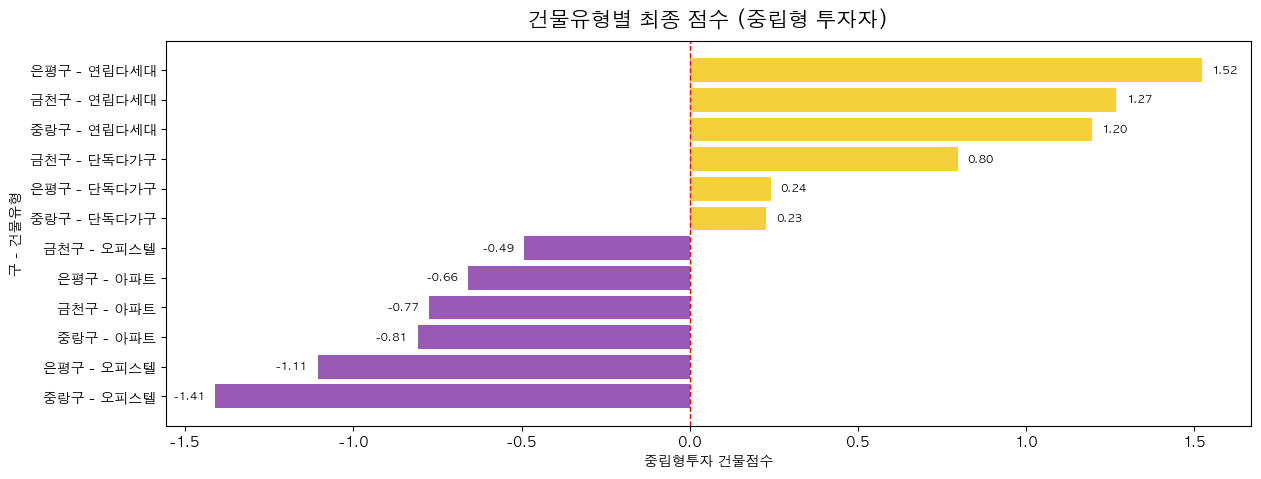

In [41]:
# 중립형 투자자 건물 유형별 최종 점수
df_neutral_rank = neutral_gu_rank[["자치구명", "건물용도", "중립형투자건물점수"]].copy()
df_neutral_rank["라벨"] = df_neutral_rank["자치구명"] + " - " + df_neutral_rank["건물용도"]
df_neutral_rank = df_neutral_rank.sort_values("중립형투자건물점수", ascending=True).reset_index(drop=True)
colors = ["#F4D13B" if v >= 0 else "#9b59b6" for v in df_neutral_rank["중립형투자건물점수"]]

plt.figure(figsize=(14, 5))
plt.barh(df_neutral_rank["라벨"], df_neutral_rank["중립형투자건물점수"], color=colors)
plt.title("건물유형별 최종 점수 (중립형 투자자)", fontsize=15, fontweight="bold", pad=10)
plt.xlabel("중립형투자 건물점수")
plt.ylabel("구 - 건물유형")
for i, v in enumerate(df_neutral_rank["중립형투자건물점수"]):
    x_pos = v + 0.03 if v >= 0 else v - 0.03
    ha = "left" if v >= 0 else "right"
    plt.text(x_pos, i, f"{v:.2f}", va="center", ha=ha, fontsize=8)
plt.axvline(0, color="red", linestyle="--", linewidth=1)
plt.show()

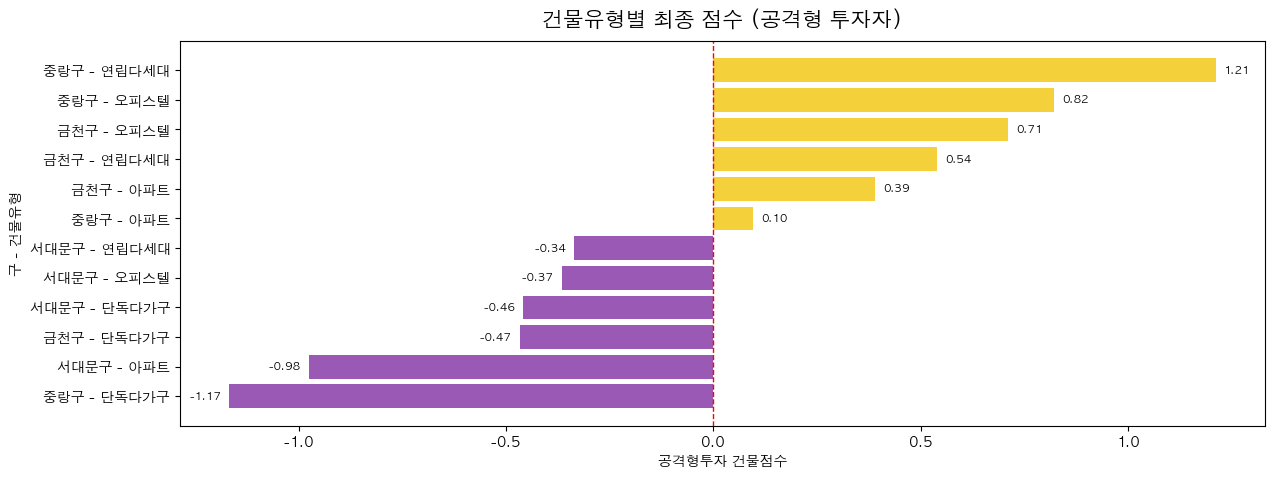

In [42]:
# 공격형 투자자 건물유형별 최종 점수
df_aggr_rank = aggr_gu_rank[["자치구명", "건물용도", "공격형투자건물점수"]].copy()
df_aggr_rank["라벨"] = df_aggr_rank["자치구명"] + " - " + df_aggr_rank["건물용도"]
df_aggr_rank = df_aggr_rank.sort_values("공격형투자건물점수", ascending=True).reset_index(drop=True)
colors = ["#F4D13B" if v >= 0 else "#9b59b6" for v in df_aggr_rank["공격형투자건물점수"]]

plt.figure(figsize=(14, 5))
plt.barh(df_aggr_rank["라벨"], df_aggr_rank["공격형투자건물점수"], color=colors)
plt.title("건물유형별 최종 점수 (공격형 투자자)", fontsize=15, fontweight="bold", pad=10)
plt.xlabel("공격형투자 건물점수")
plt.ylabel("구 - 건물유형")
for i, v in enumerate(df_aggr_rank["공격형투자건물점수"]):
    x_pos = v + 0.02 if v >= 0 else v - 0.02
    ha = "left" if v >= 0 else "right"
    plt.text(x_pos, i, f"{v:.2f}", va="center", ha=ha, fontsize=8)
plt.axvline(0, color="red", linestyle="--", linewidth=1)
plt.show()

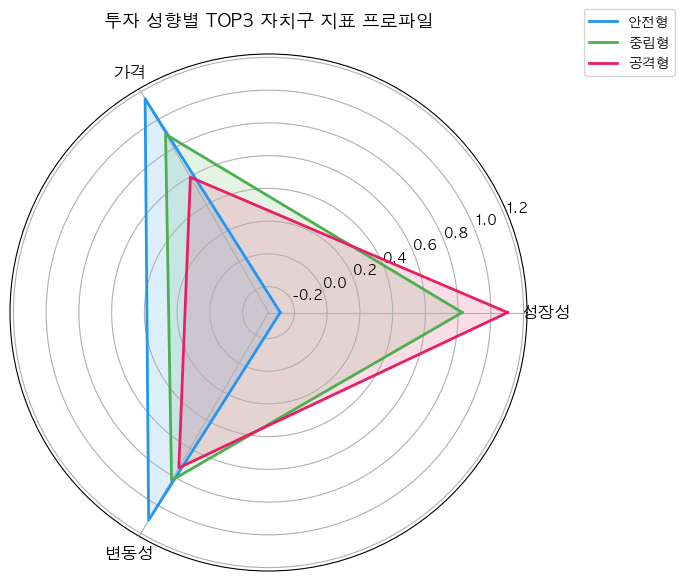

In [ ]:
# 레이더 차트 — 투자 성향별 지표 프로파일 비교
import numpy as np

def get_avg_metrics(rank_df, n=3):
    top = rank_df.head(n)
    return {
        "성장성": top["성장성점수"].mean(),
        "가격": top["가격점수"].mean(),
        "변동성": top["변동성점수"].mean(),
    }

metrics_safe = get_avg_metrics(safe_rank_gu)
metrics_neutral = get_avg_metrics(neutral_rank_gu)
metrics_aggr = get_avg_metrics(aggr_rank_gu)

categories = ["성장성", "가격", "변동성"]
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for metrics, label, color in [
    (metrics_safe,    "안전형", "#2196F3"),
    (metrics_neutral, "중립형", "#4CAF50"),
    (metrics_aggr,    "공격형", "#E91E63"),
]:
    values = [metrics[c] for c in categories]
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=label, color=color)
    ax.fill(angles, values, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_title("투자 성향별 TOP3 자치구 지표 프로파일",
             pad=20, fontsize=13, fontweight="bold")
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.tight_layout()
plt.show()

## 분석 결론 및 인사이트

### 핵심 의사결정 근거
- **Z-score 표준화**: 단위가 다른 3개 지표(성장률%, 가격만원, 변동성%)를 공정하게 합산
- **이원화 전처리**: 시장 흐름 분석(원본) vs 투자 성향 분석(IQR 정제)으로 목적에 맞게 분리
- **가중치 설계**: 세 유형 모두 합계 3.0 → 스케일 통일로 성향 간 점수 비교 가능
- **민감도 분석**: 가중치를 ±0.2 범위에서 변경해도 TOP3 순위가 안정적으로 유지됨

### 분석의 강점
- 경험·직관이 아닌 **수치 기반 투자 의사결정 프레임워크** 완성
- 단순 가격 순위가 아닌 **성장성 + 가격 + 변동성** 3개 지표 종합 평가
- 투자 성향에 따라 **자치구 + 건물유형 조합**까지 추천
- 지표 독립성 검증(상관관계 분석) 및 결과 안정성 검증(민감도 분석) 포함

### 개선 방향
- 금리, 전세가율 등 거시경제 변수 추가 시 분석 정확도 향상 가능
- 지역별 개발 호재(교통, 재개발) 정보 결합으로 미래 성장성 반영 가능
